# 01 — Exploratory Data Analysis (EDA)
## Khám Phá Dữ Liệu Sức Khỏe Tinh Thần

**Mục tiêu**: Hiểu rõ dữ liệu, tìm patterns, phát hiện vấn đề cần xử lý ở GĐ2 (Preprocessing & Feature Engineering).  

**Phương pháp phân tích**:
1. Load Data & Tổng quan
2. Phân tích Target Variable (Depression)
3. Phân tích Missing Values
4. Univariate Analysis (Numerical + Categorical)
5. Bivariate Analysis (Features vs Depression)
6. Multivariate Analysis (Tương tác đa biến)
7. Correlation Analysis
8. Key Findings & Đề xuất cho GĐ2

## Từ Điển Dữ Liệu (Data Dictionary)

Mô tả chi tiết ý nghĩa các biến (cột) trong bộ dữ liệu:

| Cột | Mô tả | Loại |
|---|---|---|
| `id` | Định danh duy nhất cho mỗi cá nhân | ID |
| `Name` | Tên cá nhân | ID |
| `Gender` | Giới tính (Male / Female) | Categorical |
| `Age` | Tuổi | Numerical |
| `City` | Thành phố sinh sống | Categorical (High Cardinality) |
| `Working Professional or Student` | Phân loại đối tượng: Người đi làm hoặc Sinh viên | Categorical (Binary) |
| `Profession` | Ngành nghề | Categorical (High Cardinality) |
| `Academic Pressure` | Áp lực học tập — chỉ dành cho Sinh viên | Numerical (Conditional) |
| `Work Pressure` | Áp lực công việc — chỉ dành cho Người đi làm | Numerical (Conditional) |
| `CGPA` | Điểm trung bình tích lũy — chỉ dành cho Sinh viên | Numerical (Conditional) |
| `Study Satisfaction` | Độ thỏa mãn với việc học — chỉ dành cho Sinh viên | Numerical (Conditional) |
| `Job Satisfaction` | Độ thỏa mãn với công việc — chỉ dành cho Người đi làm | Numerical (Conditional) |
| `Sleep Duration` | Thời gian ngủ trung bình | Categorical (Ordinal) |
| `Dietary Habits` | Thói quen ăn uống (Healthy / Moderate / Unhealthy) | Categorical (Ordinal) |
| `Degree` | Bằng cấp cao nhất đang có hoặc đang theo học | Categorical (High Cardinality) |
| `Have you ever had suicidal thoughts ?` | Đã bao giờ có ý định tự tử chưa? (Yes / No) | Categorical (Binary) |
| `Work/Study Hours` | Tổng số giờ dành cho việc học / làm mỗi ngày | Numerical |
| `Financial Stress` | Mức độ căng thẳng tài chính | Numerical |
| `Family History of Mental Illness` | Gia đình có tiền sử bệnh tâm thần không? (Yes / No) | Categorical (Binary) |
| **`Depression`** | **Trạng thái trầm cảm (0 = Không, 1 = Có) — TARGET** | **Binary Target** |

> **Lưu ý**: Các cột `Academic Pressure`, `CGPA`, `Study Satisfaction` chỉ có giá trị khi đối tượng là **Sinh viên**. Tương tự, `Work Pressure`, `Job Satisfaction` chỉ có giá trị khi đối tượng là **Người đi làm**. Đây là dạng **conditional missing** (missing có chủ đích).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Thêm src vào path để import utils
sys.path.insert(0, os.path.abspath('..'))
from src.eda_utils import *

# Cấu hình hiển thị
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'font.size': 12
})
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

---
## 1.1 Load Data & Tổng Quan

Bước đầu tiên là tải dữ liệu thô (`train.csv` và `test.csv`) và xem xét tổng quan về kích thước, kiểu dữ liệu, và cấu trúc chung. Phần này giúp có cái nhìn toàn cảnh về dataset trước khi đi sâu vào phân tích từng khía cạnh.

In [2]:
# Load dữ liệu
train_df = pd.read_csv('../data/raw/train.csv')
test_df = pd.read_csv('../data/raw/test.csv')

print(f'Train set: {train_df.shape[0]:,} dòng × {train_df.shape[1]} cột')
print(f'Test set:  {test_df.shape[0]:,} dòng × {test_df.shape[1]} cột')

Train set: 140,700 dòng × 20 cột
Test set:  93,800 dòng × 19 cột


In [3]:
# Xem 5 dòng đầu tiên
train_df.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [4]:
# Thông tin chi tiết về kiểu dữ liệu và non-null counts
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  str    
 2   Gender                                 140700 non-null  str    
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  str    
 5   Working Professional or Student        140700 non-null  str    
 6   Profession                             104070 non-null  str    
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   float64
 11

In [5]:
# Bảng tổng quan tất cả các cột
overview = create_overview_table(train_df)
overview

,Kiểu dữ liệu,Số missing,% missing,Số unique,Giá trị mẫu
id,int64,0,0.00,140700,0
Name,str,0,0.00,422,Aaradhya
Gender,str,0,0.00,2,Female
Age,float64,0,0.00,43,49.0
City,str,0,0.00,98,Ludhiana
Working Professional or Student,str,0,0.00,2,Working Professional
Profession,str,36630,26.03,64,Chef
Academic Pressure,float64,112803,80.17,5,5.0
Work Pressure,float64,27918,19.84,5,5.0
CGPA,float64,112802,80.17,331,8.97


### Nhận xét tổng quan

**Kích thước dữ liệu**: Dataset gồm **140,700 mẫu** với **20 cột** (train) — đây là một bộ dữ liệu khá lớn, đủ để training các model phức tạp mà ít lo overfitting do thiếu data.

**Kiểu dữ liệu**: Hỗn hợp giữa numerical (8 cột: `Age`, `CGPA`, các thang đo áp lực/hài lòng, ...) và categorical (9 cột: `Gender`, `City`, `Profession`, ...). Đáng chú ý, nhiều cột categorical thực chất mang tính **ordinal** (`Sleep Duration`, `Dietary Habits`) — cần encoding phù hợp ở GĐ2.

**Missing values**: Có **5 cột missing đáng kể** (`Academic Pressure`, `CGPA`, `Study Satisfaction` mỗi cột ~80%, `Work Pressure`, `Job Satisfaction` mỗi cột ~20%). Tuy nhiên, đây KHÔNG phải missing ngẫu nhiên — chúng mang tính **conditional** (sẽ phân tích kỹ hơn ở mục 1.3). Ngoài ra có 3 cột (`Dietary Habits`, `Degree`, `Financial Stress`) missing rất ít (2-4 mẫu), có thể xử lý đơn giản.

**Dữ liệu bẩn (dirty data)**: Qua quan sát sơ bộ, nhiều cột categorical chứa giá trị bất thường (ví dụ: `Sleep Duration` có 36 unique thay vì 4 category mong đợi, `Dietary Habits` có 23 unique thay vì 3). Đây là vấn đề cần xử lý kỹ ở GĐ2.

---
## 1.2 Phân Tích Target Variable (`Depression`)

Trước khi phân tích các features, cần hiểu phân phối của biến mục tiêu `Depression`. Nếu data bị **mất cân bằng (imbalanced)** nghiêm trọng, sẽ ảnh hưởng đến cách chọn model, metric đánh giá, và có thể cần áp dụng các kỹ thuật xử lý imbalance (SMOTE, class weight, ...) ở các giai đoạn sau.

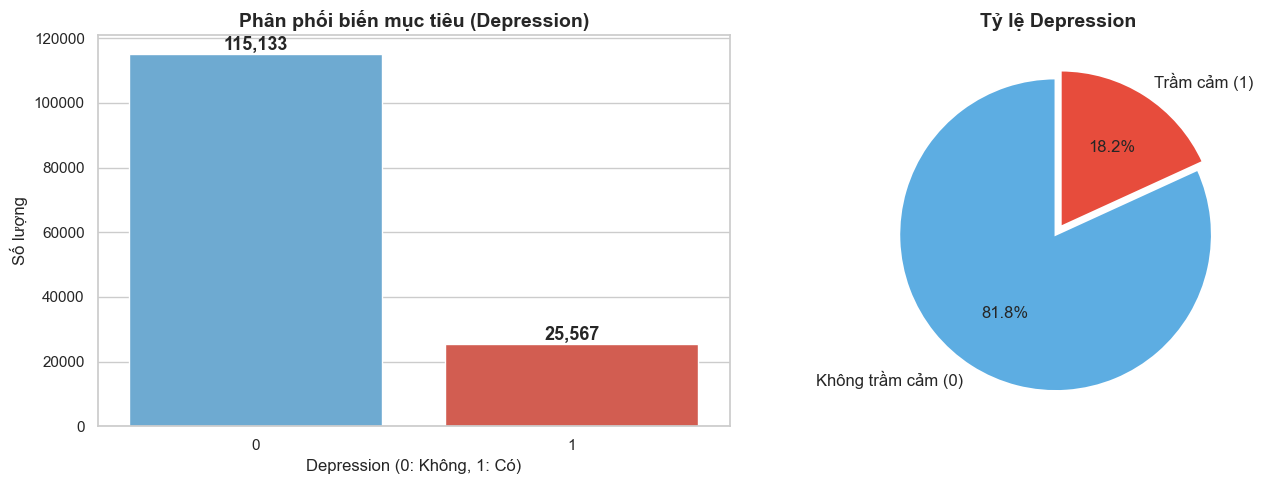

Tỷ lệ Depression:
  Depression = 0: 81.83%  (115,133 mẫu)
  Depression = 1: 18.17%  (25,567 mẫu)
  Tỷ số (class 1 / class 0): 0.222


In [6]:
# Phân phối biến mục tiêu Depression
plot_target_distribution(train_df, target='Depression')

### Nhận xét Target Variable

**Phân phối**: Dataset có **81.83% Không trầm cảm** (115,133 mẫu) và **18.17% Trầm cảm** (25,567 mẫu) — tỷ số class 1/class 0 khoảng **0.222**, tức cứ 5 người thì có khoảng 1 người bị trầm cảm.

**Mức độ imbalanced**: Data bị mất cân bằng ở mức **vừa phải** (moderate imbalance). Tỷ lệ 82:18 chưa đến mức cực đoan (như 99:1), nhưng đủ để gây bias — model có thể có xu hướng "lười" và predict hầu hết là class 0 để đạt accuracy ~82% mà không thực sự học được pattern.

**Khuyến nghị cho GĐ2/GĐ3**:
- Sử dụng **F1-score** (trung bình harmonic giữa Precision và Recall) làm metric chính thay vì chỉ accuracy
- Cân nhắc dùng `class_weight='balanced'` trong các model (Logistic Regression, Random Forest, ...)
- Hoặc áp dụng **SMOTE** (Synthetic Minority Over-sampling) nếu cần, nhưng thận trọng vì dataset đã khá lớn (140K mẫu)

---
## 1.3 Phân Tích Missing Values

Dataset này có đặc điểm **conditional missing** — một số cột chỉ có giá trị khi đối tượng là Student hoặc Working Professional:
- `Academic Pressure`, `CGPA`, `Study Satisfaction` → chỉ có giá trị ở **Student**
- `Work Pressure`, `Job Satisfaction` → chỉ có giá trị ở **Working Professional**

Việc hiểu rõ pattern missing sẽ quyết định chiến lược xử lý ở GĐ2 (Preprocessing).

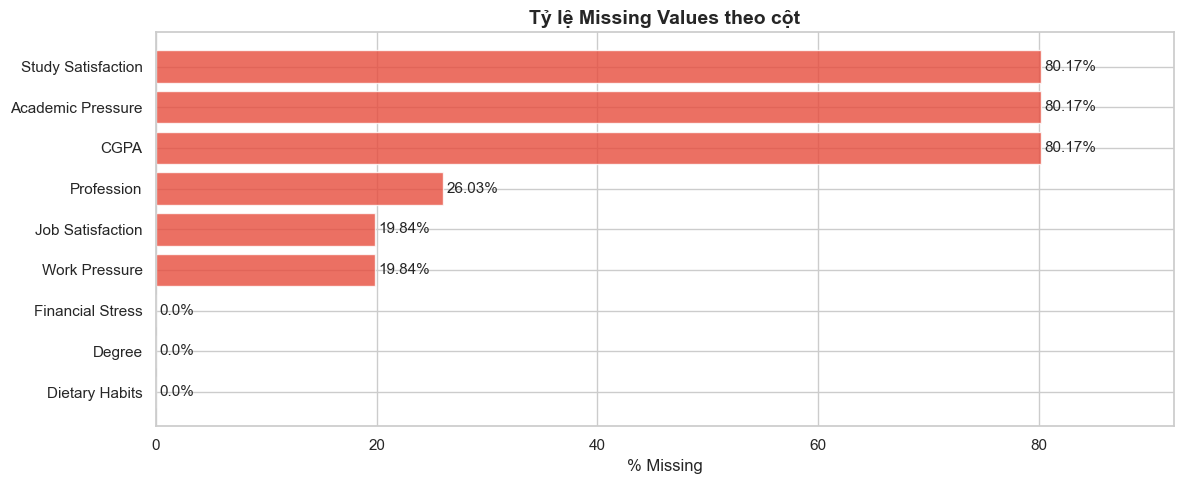


📋 Chi tiết Missing Values:


,Số missing,% missing
Academic Pressure,112803,80.17
CGPA,112802,80.17
Study Satisfaction,112803,80.17
Profession,36630,26.03
Work Pressure,27918,19.84
Job Satisfaction,27910,19.84
Dietary Habits,4,0.00
Degree,2,0.00
Financial Stress,4,0.00


In [7]:
# Tổng quan missing values
plot_missing_values(train_df)

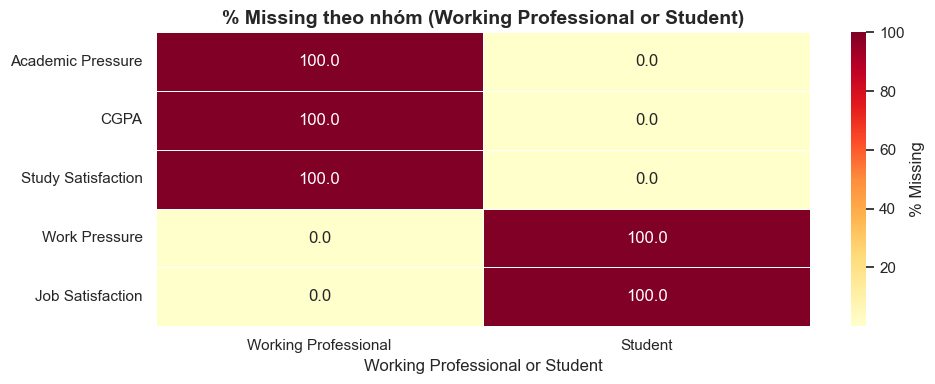


📋 Chi tiết missing theo nhóm:

--- Working Professional (112,799 mẫu) ---
  Academic Pressure: 112,794 missing (100.0%)
  CGPA: 112,793 missing (100.0%)
  Study Satisfaction: 112,793 missing (100.0%)
  Work Pressure: 20 missing (0.0%)
  Job Satisfaction: 17 missing (0.0%)

--- Student (27,901 mẫu) ---
  Academic Pressure: 9 missing (0.0%)
  CGPA: 9 missing (0.0%)
  Study Satisfaction: 10 missing (0.0%)
  Work Pressure: 27,898 missing (100.0%)
  Job Satisfaction: 27,893 missing (100.0%)


In [8]:
# Phân tích pattern missing: Student vs Working Professional
plot_missing_pattern_by_group(
    train_df,
    group_col='Working Professional or Student',
    cols=['Academic Pressure', 'CGPA', 'Study Satisfaction',
          'Work Pressure', 'Job Satisfaction']
)

### Nhận xét Missing Values

**Pattern rõ ràng — Conditional Missing**: Kết quả heatmap xác nhận giả thuyết ban đầu:
- `Academic Pressure`, `CGPA`, `Study Satisfaction` → missing **~100% ở Working Professional** và chỉ missing vài mẫu (~0.03%) ở Student
- `Work Pressure`, `Job Satisfaction` → missing **~100% ở Student** và chỉ missing vài mẫu (~0.01-0.02%) ở Working Professional

Đây là dạng **Missing Not At Random (MNAR)** — một sinh viên không có `Work Pressure` không phải do mất data, mà vì *câu hỏi đó không áp dụng cho họ*. Tương tự với người đi làm không có `Academic Pressure`.

**Phát hiện thú vị**: Trong nhóm Student vẫn có ~9-10 mẫu missing ở các cột lẽ ra phải có giá trị (`Academic Pressure`, `CGPA`, `Study Satisfaction`). Tương tự, nhóm Worker có ~17-20 mẫu missing ở `Work Pressure`, `Job Satisfaction`. Đây có thể là do lỗi nhập liệu hoặc người dùng bỏ qua.

**Đề xuất hướng xử lý cho GĐ2**:
- **Ưu tiên Cách 1 (Merge)**: Tạo cột gộp `Pressure` = `Academic Pressure` (nếu Student) hoặc `Work Pressure` (nếu Professional). Tương tự `Satisfaction` = `Study Satisfaction` / `Job Satisfaction`. Cách này bảo toàn ý nghĩa semantic và không tạo giá trị giả.
- **Cách 2 (Fill)**: Nếu cần giữ riêng, fill missing ở vài mẫu lẻ bằng median theo nhóm (Student/Professional)
- `CGPA`: Chỉ áp dụng cho Student, có thể fill NaN của Professional bằng 0 hoặc tạo flag `has_CGPA`
- 3 cột missing ít (`Dietary Habits`: 4, `Degree`: 2, `Financial Stress`: 4) → fill bằng mode hoặc drop mẫu

---
## 1.4 Univariate Analysis — Numerical Features

Phân tích phân phối của từng biến số (numerical) bằng **histogram + KDE**, **boxplot**, và **thống kê mô tả**. Mục tiêu: phát hiện phân phối lệch (skewed), outliers, và các đặc điểm bất thường của dữ liệu.

**Các biến numerical**: `Age`, `Academic Pressure`, `Work Pressure`, `CGPA`, `Study Satisfaction`, `Job Satisfaction`, `Work/Study Hours`, `Financial Stress`

In [9]:
# Danh sách numerical features
numerical_cols = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
                  'Study Satisfaction', 'Job Satisfaction',
                  'Work/Study Hours', 'Financial Stress']

# Thống kê mô tả tổng quan
train_df[numerical_cols].describe().round(2)

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress
count,140700.00,27897.00,112782.00,27898.00,27897.00,112790.00,140700.00,140696.00
mean,40.39,3.14,3.00,7.66,2.94,2.97,6.25,2.99
std,12.38,1.38,1.41,1.46,1.36,1.42,3.85,1.41
min,18.00,1.00,1.00,5.03,1.00,1.00,0.00,1.00
25%,29.00,2.00,2.00,6.29,2.00,2.00,3.00,2.00
50%,42.00,3.00,3.00,7.77,3.00,3.00,6.00,3.00
75%,51.00,4.00,4.00,8.92,4.00,4.00,10.00,4.00
max,60.00,5.00,5.00,10.00,5.00,5.00,12.00,5.00


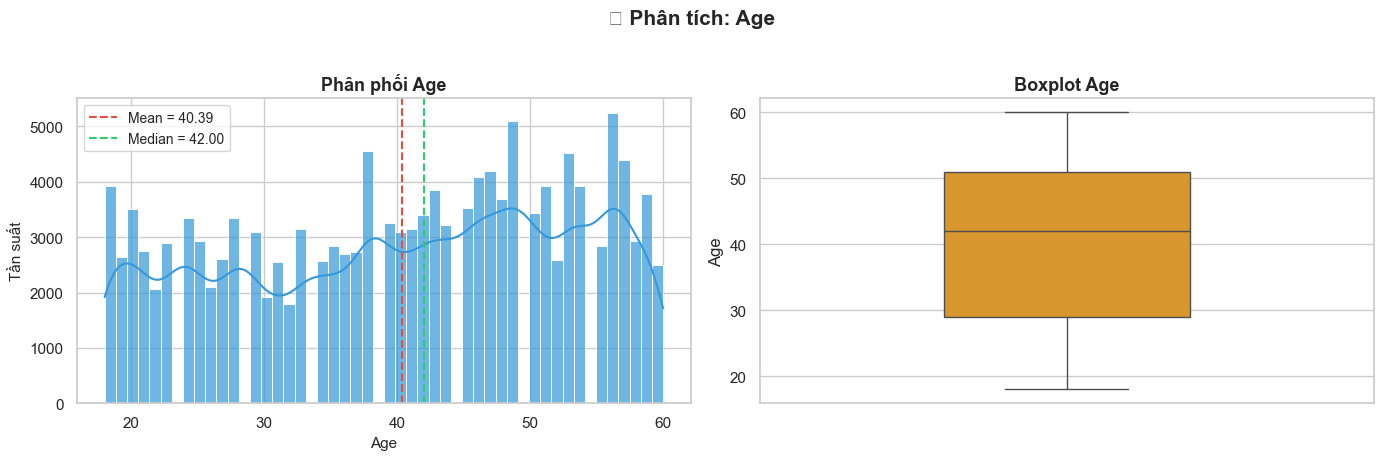

  Skewness: -0.218 | Kurtosis: -1.149
  Mean: 40.39 | Std: 12.38 | Min: 18.00 | Max: 60.00
  Q1: 29.00 | Q3: 51.00 | IQR: 22.00
  Outliers (IQR method): 0 thấp, 0 cao (tổng 0)
----------------------------------------------------------------------


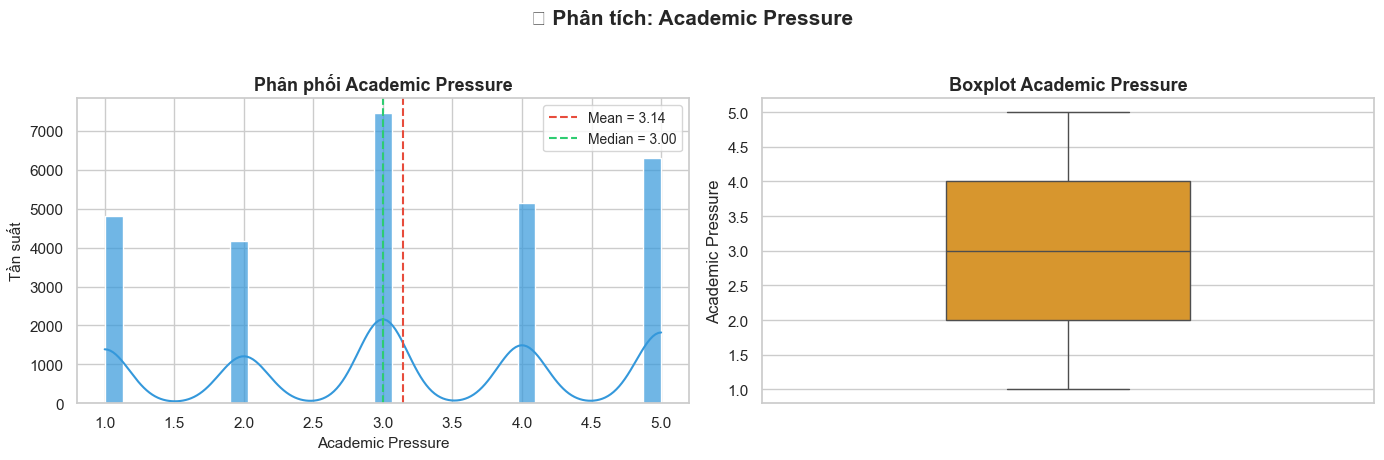

  Skewness: -0.134 | Kurtosis: -1.164
  Mean: 3.14 | Std: 1.38 | Min: 1.00 | Max: 5.00
  Q1: 2.00 | Q3: 4.00 | IQR: 2.00
  Outliers (IQR method): 0 thấp, 0 cao (tổng 0)
----------------------------------------------------------------------


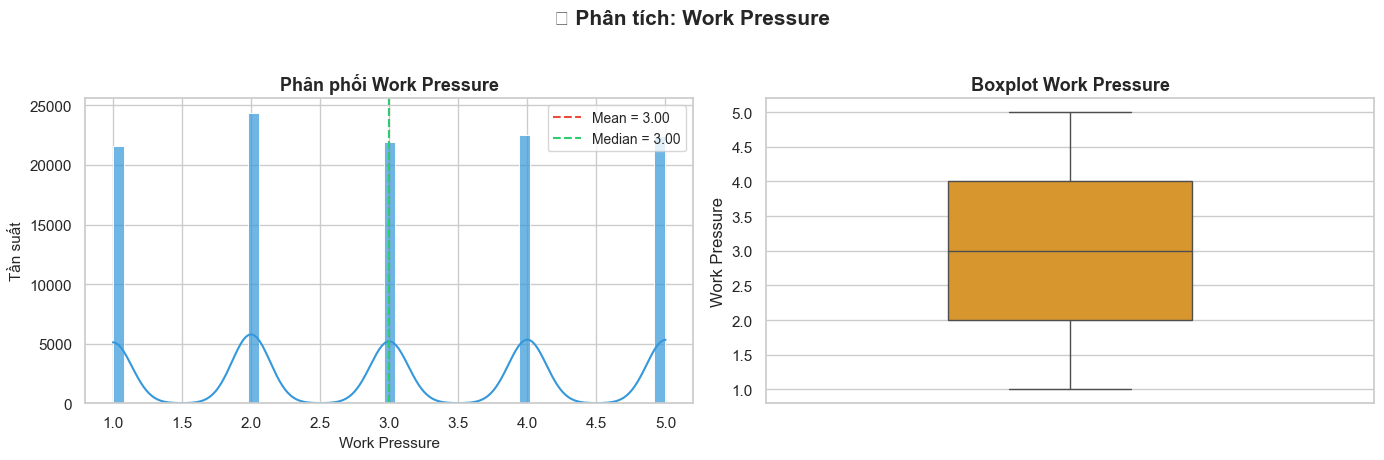

  Skewness: 0.019 | Kurtosis: -1.295
  Mean: 3.00 | Std: 1.41 | Min: 1.00 | Max: 5.00
  Q1: 2.00 | Q3: 4.00 | IQR: 2.00
  Outliers (IQR method): 0 thấp, 0 cao (tổng 0)
----------------------------------------------------------------------


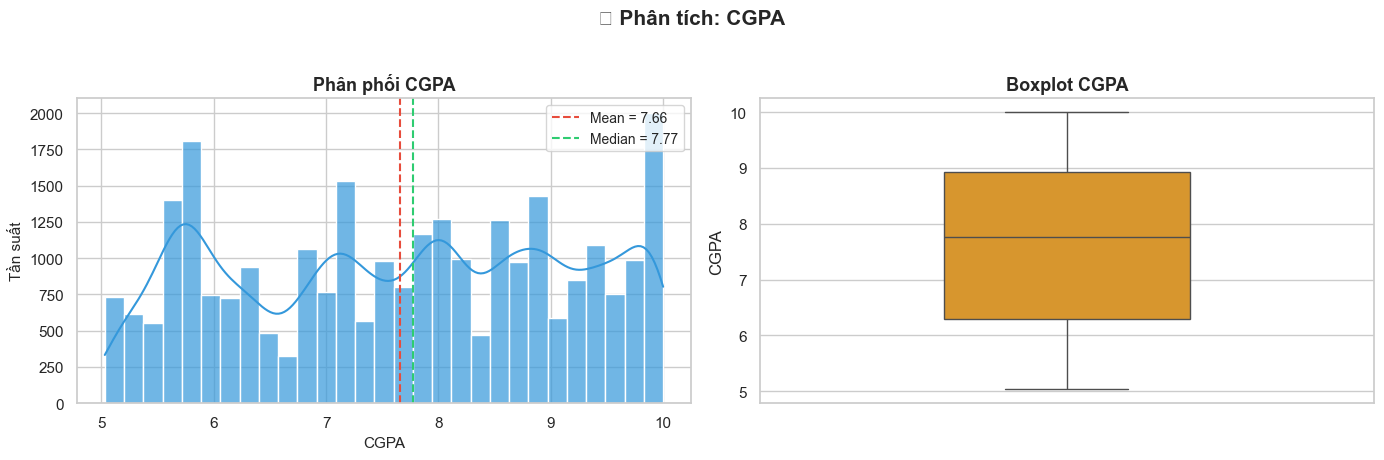

  Skewness: -0.074 | Kurtosis: -1.229
  Mean: 7.66 | Std: 1.46 | Min: 5.03 | Max: 10.00
  Q1: 6.29 | Q3: 8.92 | IQR: 2.63
  Outliers (IQR method): 0 thấp, 0 cao (tổng 0)
----------------------------------------------------------------------


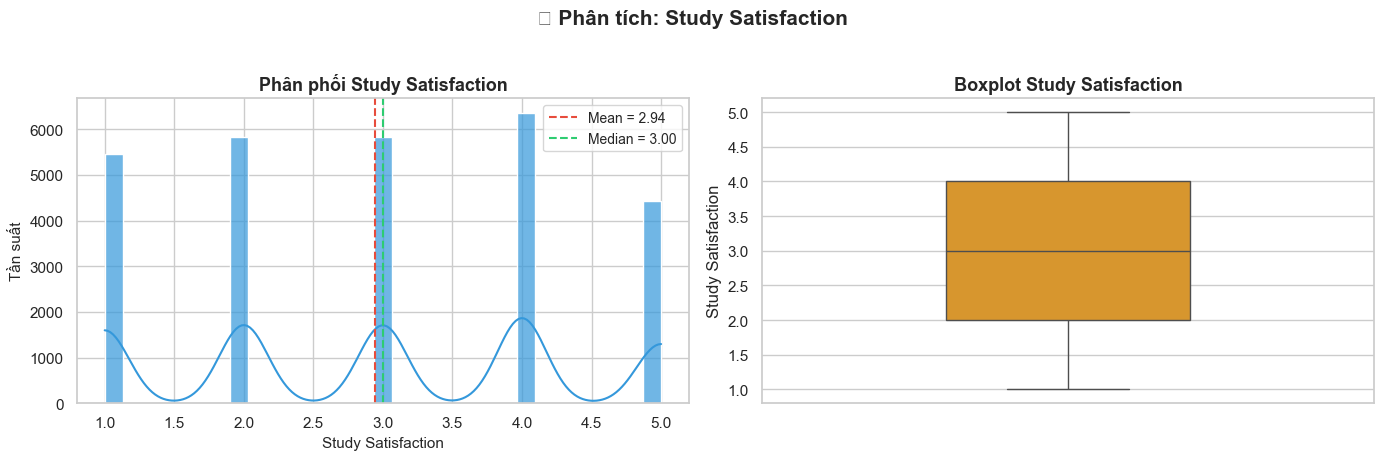

  Skewness: 0.012 | Kurtosis: -1.226
  Mean: 2.94 | Std: 1.36 | Min: 1.00 | Max: 5.00
  Q1: 2.00 | Q3: 4.00 | IQR: 2.00
  Outliers (IQR method): 0 thấp, 0 cao (tổng 0)
----------------------------------------------------------------------


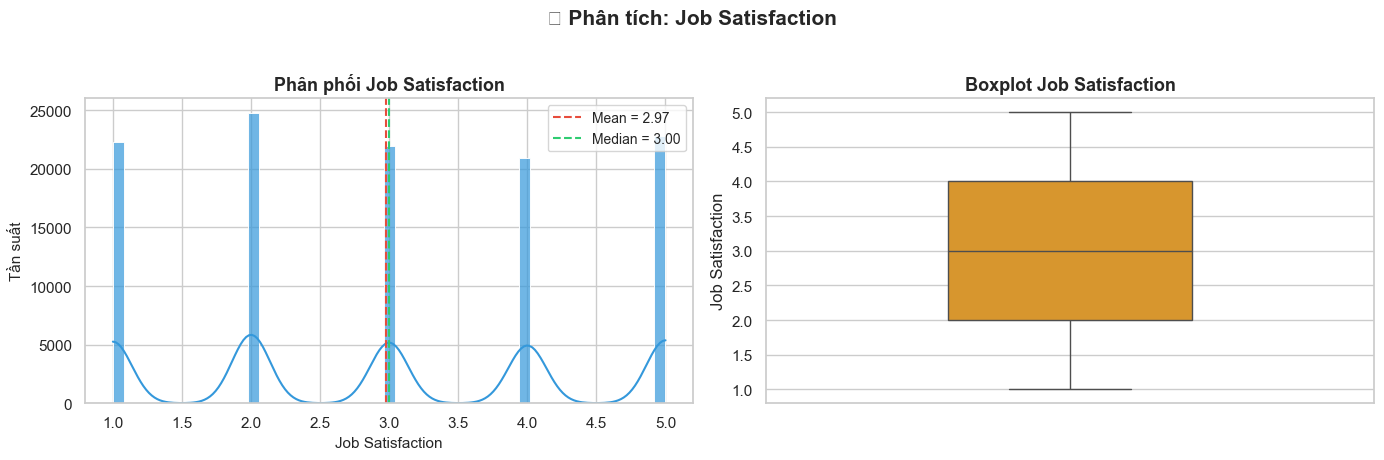

  Skewness: 0.054 | Kurtosis: -1.305
  Mean: 2.97 | Std: 1.42 | Min: 1.00 | Max: 5.00
  Q1: 2.00 | Q3: 4.00 | IQR: 2.00
  Outliers (IQR method): 0 thấp, 0 cao (tổng 0)
----------------------------------------------------------------------


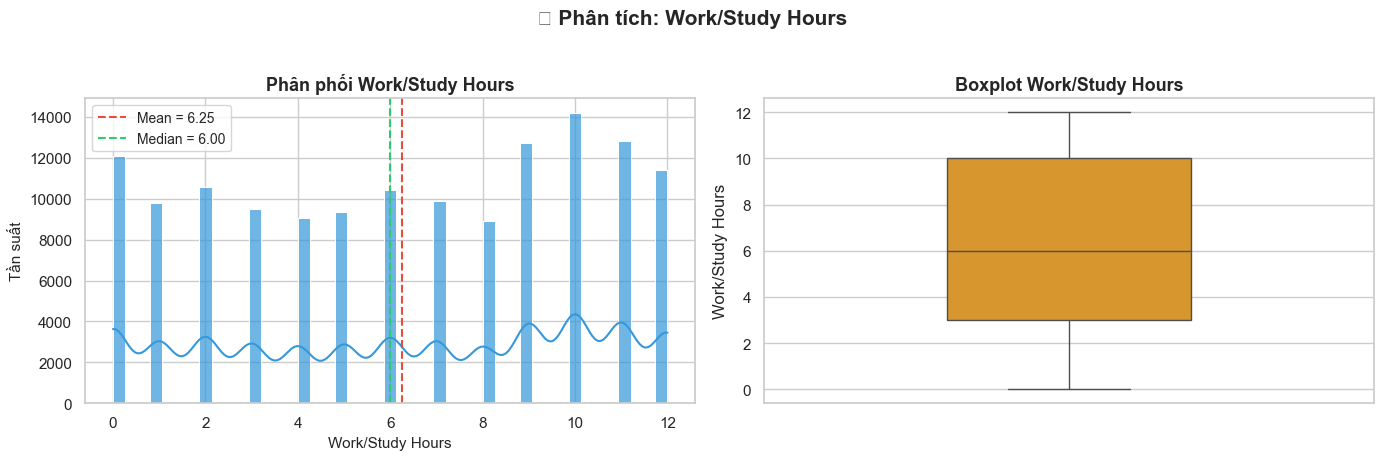

  Skewness: -0.128 | Kurtosis: -1.283
  Mean: 6.25 | Std: 3.85 | Min: 0.00 | Max: 12.00
  Q1: 3.00 | Q3: 10.00 | IQR: 7.00
  Outliers (IQR method): 0 thấp, 0 cao (tổng 0)
----------------------------------------------------------------------


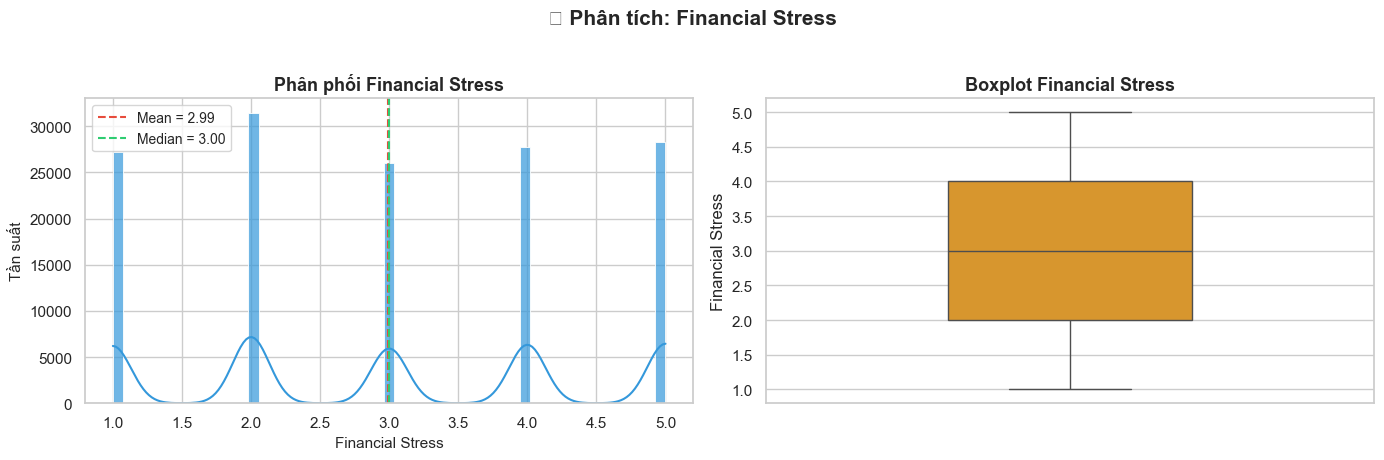

  Skewness: 0.036 | Kurtosis: -1.314
  Mean: 2.99 | Std: 1.41 | Min: 1.00 | Max: 5.00
  Q1: 2.00 | Q3: 4.00 | IQR: 2.00
  Outliers (IQR method): 0 thấp, 0 cao (tổng 0)
----------------------------------------------------------------------


In [10]:
# Vẽ phân phối cho từng numerical feature
for col in numerical_cols:
    plot_numerical_distribution(train_df, col)

### Nhận xét Numerical Features

**Age**: Phân phối khá đều trong khoảng 18-60 tuổi (mean=40.4, std=12.4), hơi lệch trái nhẹ (skew=-0.218). Kurtosis âm (-1.149) cho thấy phân phối phẳng hơn phân phối chuẩn — dữ liệu trải đều, không tập trung ở trung tâm. **Không có outliers** theo IQR.

**Academic Pressure**: Thang 1-5, mean=3.14, phân phối gần đối xứng (skew=-0.134). Đa số sinh viên chịu áp lực học tập ở mức trung bình đến cao.

**Work Pressure**: Thang 1-5, mean=3.00, gần như đối xứng hoàn hảo (skew=0.019). Phân phối cân bằng giữa các mức áp lực.

**CGPA**: Phân phối trong khoảng 5.03-10.00 (mean=7.66), rất gần phân phối chuẩn (skew=-0.074). Đa số sinh viên có điểm trung bình ở mức khá.

**Study Satisfaction & Job Satisfaction**: Cả hai đều trên thang 1-5, mean ~3.0, phân phối rất đối xứng. Nhìn chung, mức độ hài lòng phân bố đều ở tất cả các mức.

**Work/Study Hours**: Phân phối 0-12 giờ/ngày (mean=6.25, std=3.85), hơi lệch trái nhẹ (skew=-0.128). Khoảng cách giữa Q1=3 và Q3=10 khá rộng, cho thấy sự đa dạng lớn trong giờ làm/học.

**Financial Stress**: Thang 1-5, mean=2.99, phân phối gần đối xứng (skew=0.036). Căng thẳng tài chính phân bố đều ở tất cả các mức.

**Tổng kết**:
- **Outliers**: Hầu như **không có outliers** đáng kể ở bất kỳ numerical feature nào (theo phương pháp IQR 1.5×) — điều này hợp lý vì hầu hết đều là thang đo giới hạn (1-5, 0-12).
- **Skewness**: Tất cả features đều có |skew| < 0.25 → phân phối gần đối xứng, **không cần log/sqrt transform**.
- Tuy nhiên, `Age` có dấu hiệu bimodal (nhóm trẻ 18-30 vs nhóm lớn tuổi 35-60) — có thể liên quan đến Student vs Professional.

---
## 1.5 Univariate Analysis — Categorical Features

Phân tích tần suất của từng biến phân loại (categorical). Với các cột có **high cardinality** (nhiều category như `City`, `Profession`, `Degree`), chỉ hiển thị top 15-20. Mục tiêu: phát hiện các category hiếm cần gom nhóm, phân phối không đều, hoặc giá trị bất thường.

**Các biến categorical**: `Gender`, `City`, `Working Professional or Student`, `Profession`, `Sleep Duration`, `Dietary Habits`, `Degree`, `Have you ever had suicidal thoughts ?`, `Family History of Mental Illness`

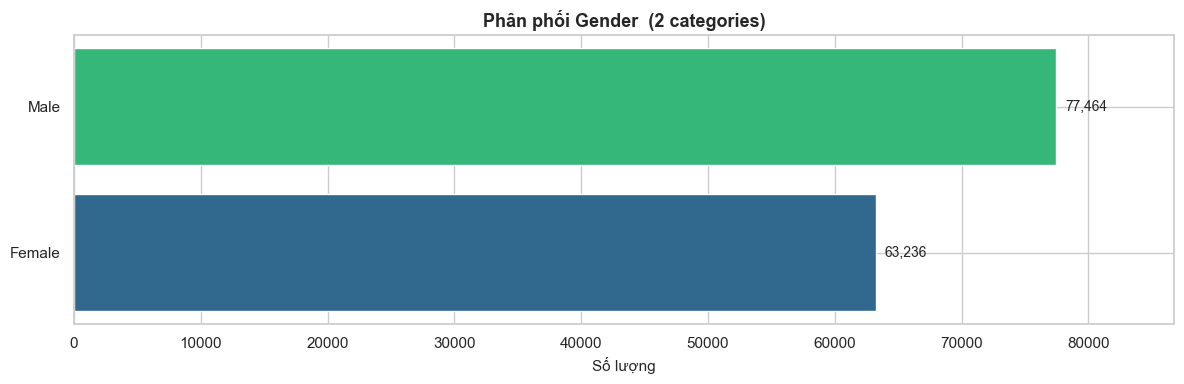


📋 Frequency Table — Gender (hiển thị top 2):


,Số lượng,% tổng
Gender,,
Male,77464,55.06
Female,63236,44.94


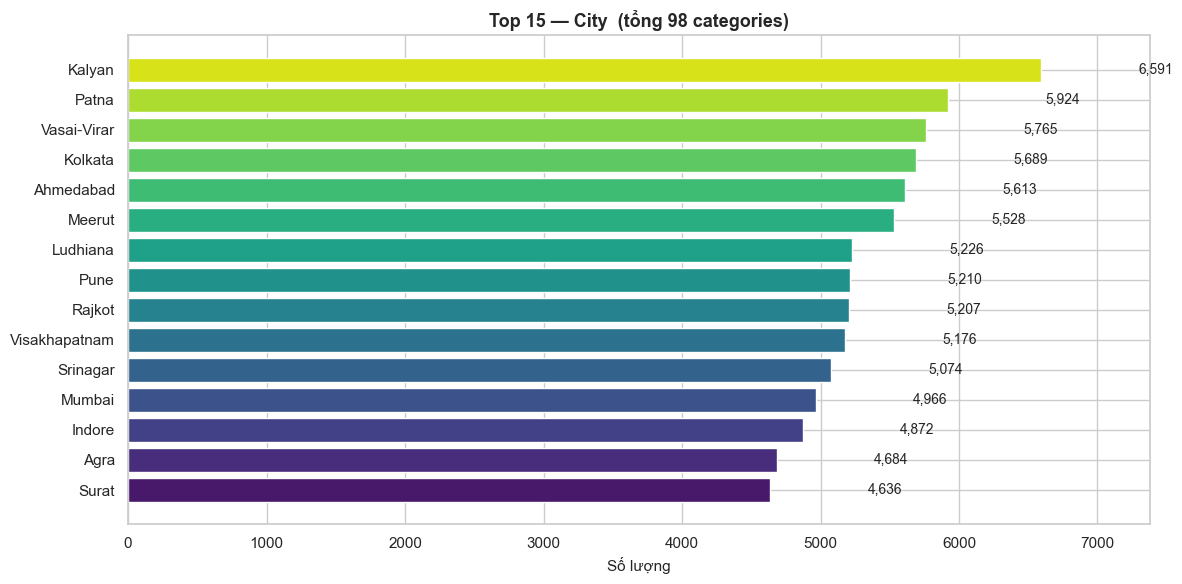


📋 Frequency Table — City (hiển thị top 20):


,Số lượng,% tổng
City,,
Kalyan,6591,4.68
Patna,5924,4.21
Vasai-Virar,5765,4.10
Kolkata,5689,4.04
Ahmedabad,5613,3.99
Meerut,5528,3.93
Ludhiana,5226,3.71
Pune,5210,3.70
Rajkot,5207,3.70


  ... và 78 categories khác


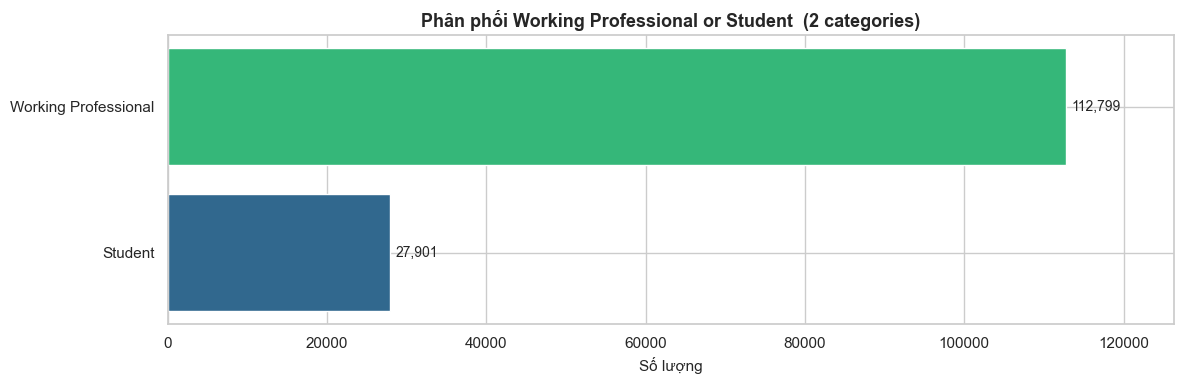


📋 Frequency Table — Working Professional or Student (hiển thị top 2):


,Số lượng,% tổng
Working Professional or Student,,
Working Professional,112799,80.17
Student,27901,19.83


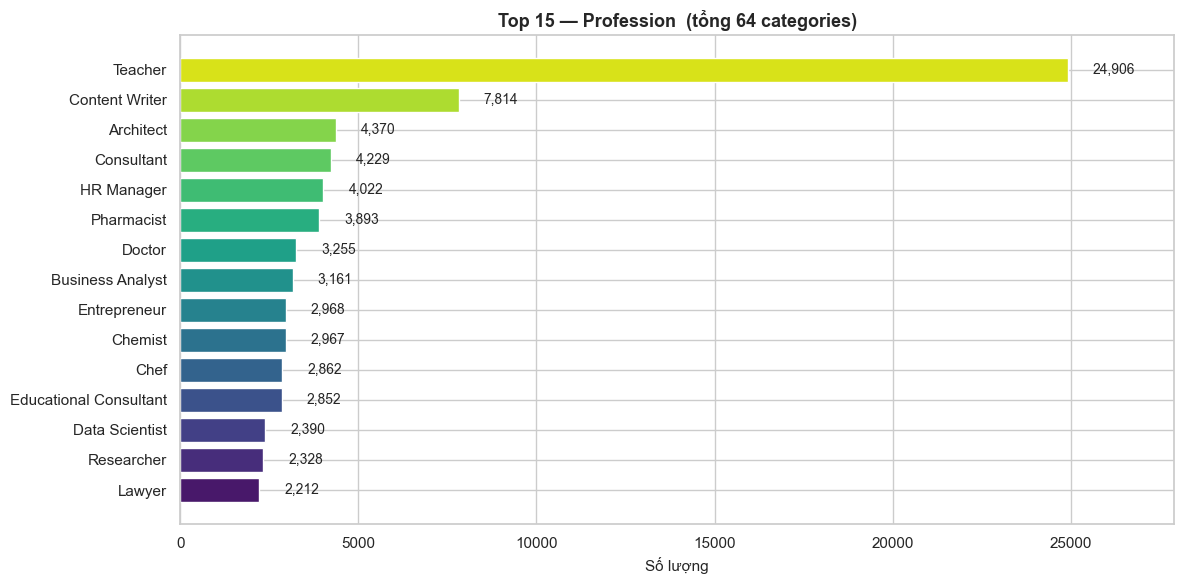


📋 Frequency Table — Profession (hiển thị top 20):


,Số lượng,% tổng
Profession,,
Teacher,24906,17.70
Content Writer,7814,5.55
Architect,4370,3.11
Consultant,4229,3.01
HR Manager,4022,2.86
Pharmacist,3893,2.77
Doctor,3255,2.31
Business Analyst,3161,2.25
Entrepreneur,2968,2.11


  ... và 44 categories khác


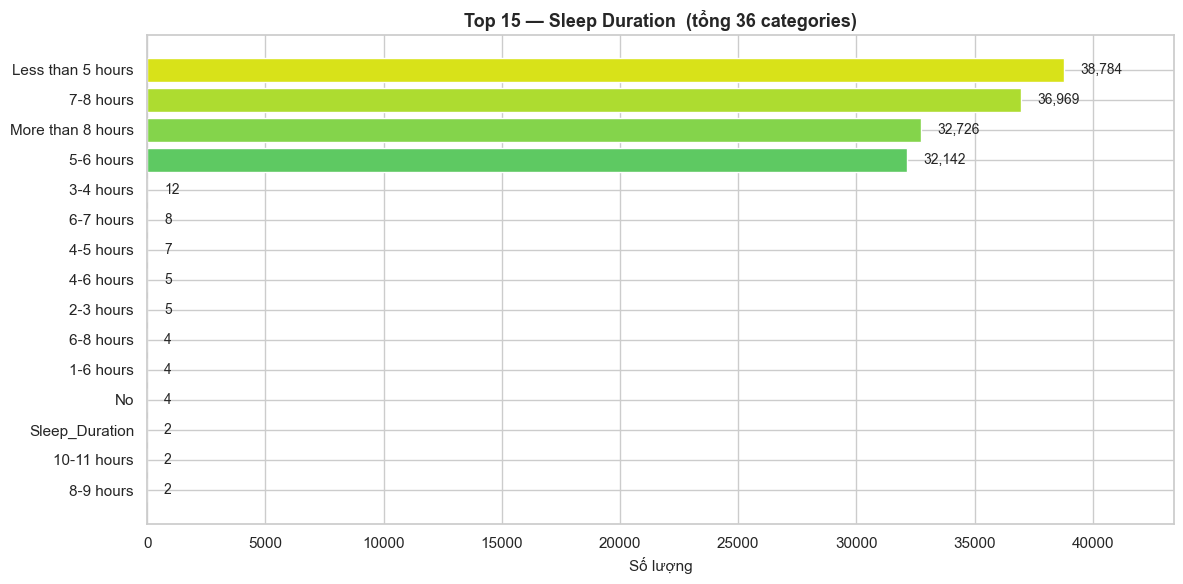


📋 Frequency Table — Sleep Duration (hiển thị top 20):


,Số lượng,% tổng
Sleep Duration,,
Less than 5 hours,38784,27.57
7-8 hours,36969,26.28
More than 8 hours,32726,23.26
5-6 hours,32142,22.84
3-4 hours,12,0.01
6-7 hours,8,0.01
4-5 hours,7,0.00
4-6 hours,5,0.00
2-3 hours,5,0.00


  ... và 16 categories khác


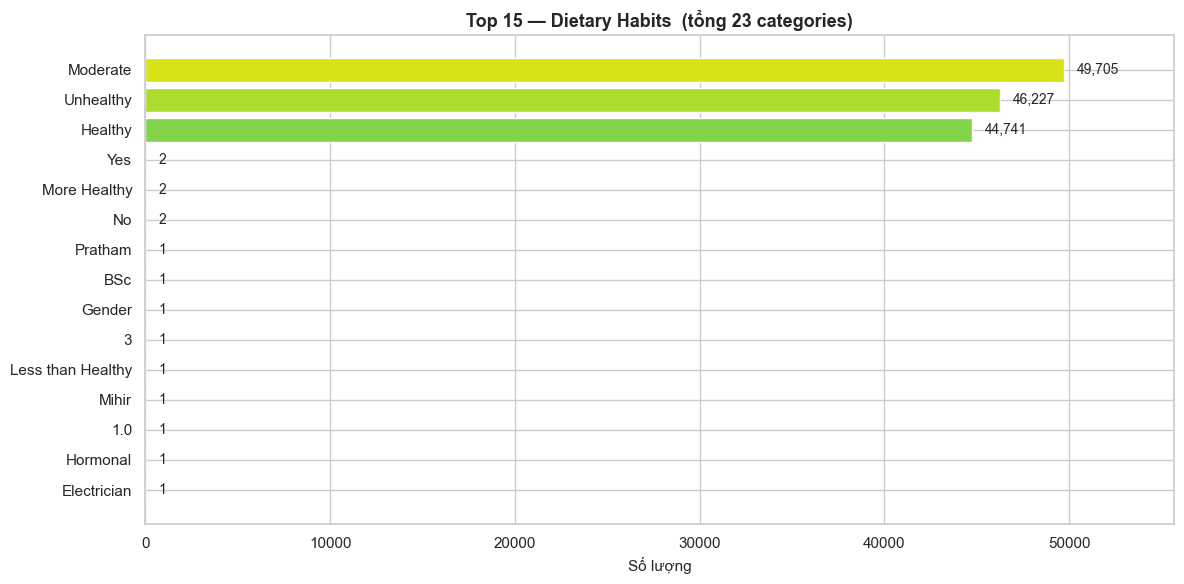


📋 Frequency Table — Dietary Habits (hiển thị top 20):


,Số lượng,% tổng
Dietary Habits,,
Moderate,49705,35.33
Unhealthy,46227,32.86
Healthy,44741,31.80
Yes,2,0.00
More Healthy,2,0.00
No,2,0.00
Pratham,1,0.00
BSc,1,0.00
Gender,1,0.00


  ... và 3 categories khác


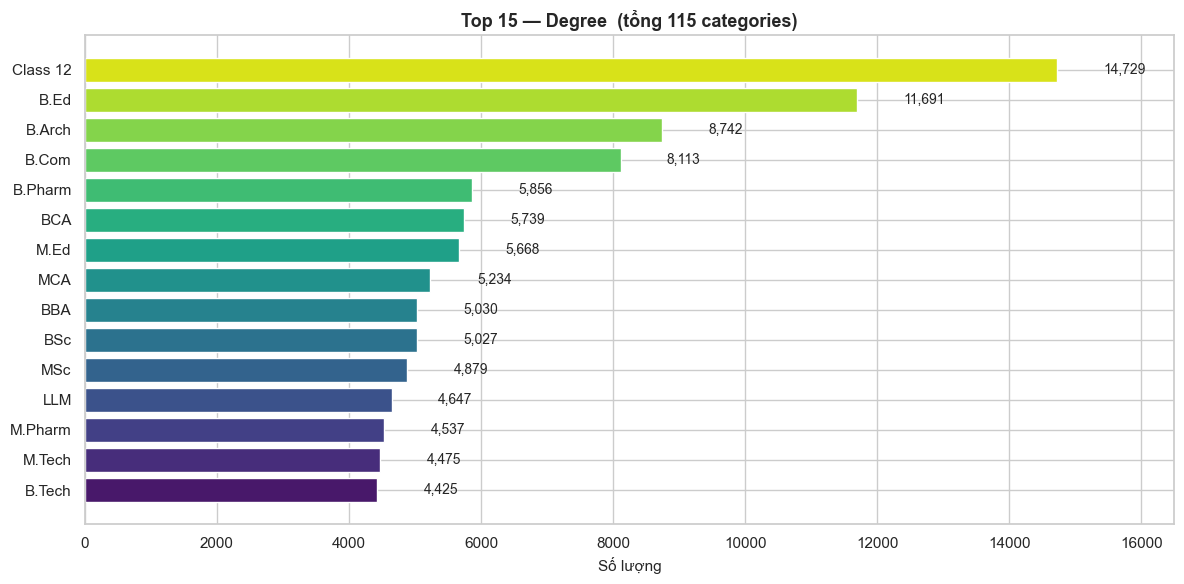


📋 Frequency Table — Degree (hiển thị top 20):


,Số lượng,% tổng
Degree,,
Class 12,14729,10.47
B.Ed,11691,8.31
B.Arch,8742,6.21
B.Com,8113,5.77
B.Pharm,5856,4.16
BCA,5739,4.08
M.Ed,5668,4.03
MCA,5234,3.72
BBA,5030,3.57


  ... và 95 categories khác


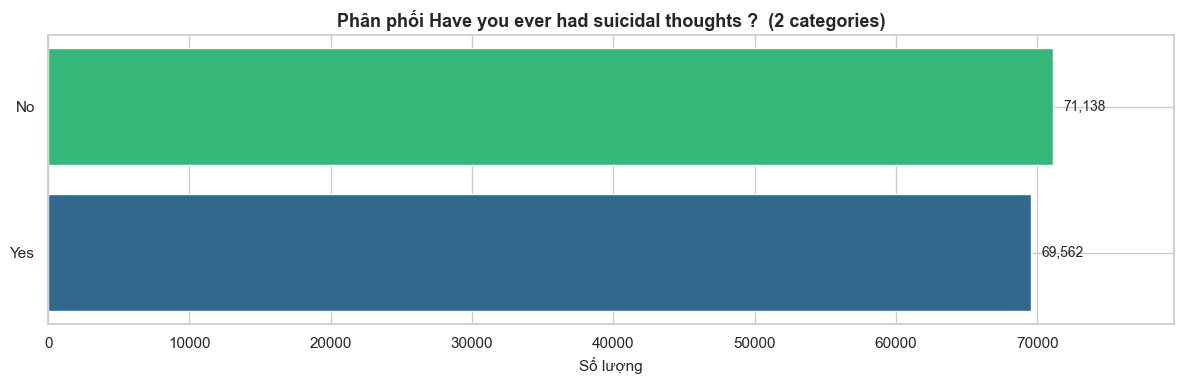


📋 Frequency Table — Have you ever had suicidal thoughts ? (hiển thị top 2):


,Số lượng,% tổng
Have you ever had suicidal thoughts ?,,
No,71138,50.56
Yes,69562,49.44


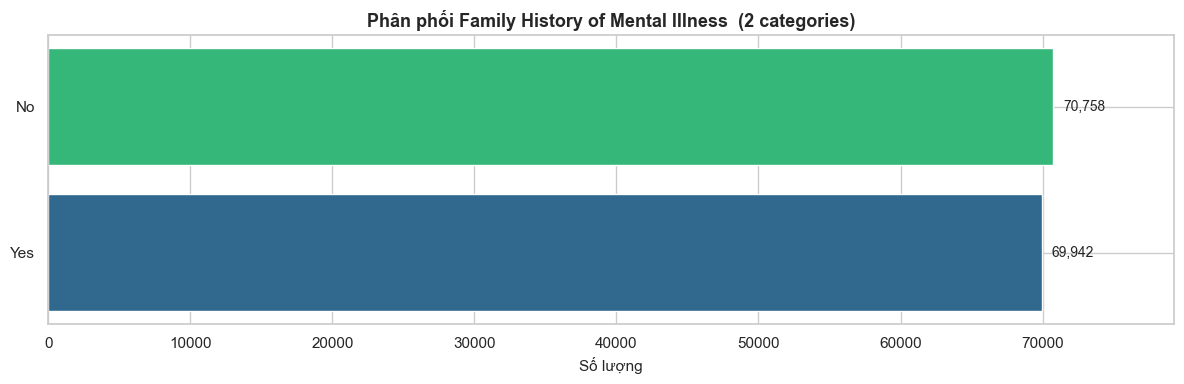


📋 Frequency Table — Family History of Mental Illness (hiển thị top 2):


,Số lượng,% tổng
Family History of Mental Illness,,
No,70758,50.29
Yes,69942,49.71


In [11]:
# Danh sách categorical features
categorical_cols = ['Gender', 'City', 'Working Professional or Student',
                    'Profession', 'Sleep Duration', 'Dietary Habits',
                    'Degree', 'Have you ever had suicidal thoughts ?',
                    'Family History of Mental Illness']

# Vẽ phân phối cho từng categorical feature
for col in categorical_cols:
    plot_categorical_distribution(train_df, col, top_n=15)

### Nhận xét Categorical Features

**Gender**: Chỉ 2 categories — Male (77,464 = 55%) chiếm đa số, Female (63,236 = 45%). Phân phối tương đối cân bằng.

**City**: **98 unique** — High cardinality! Top cities: Kalyan (6,591), Vasai-Virar (4,267). Không thể One-Hot Encoding → cần **Target Encoding** ở GĐ2b.

**Working Professional or Student**: 2 categories — Working Professional chiếm **80.2%** (112,799), Student chỉ **19.8%** (27,901). Mất cân bằng lớn giữa 2 nhóm.

**Profession**: **64 unique** — High cardinality! Top: Teacher (24,906), rồi đến nhiều ngành nghề khác nhau. Cần Target Encoding.

**Sleep Duration** **DỮ LIỆU BẨN NGHIÊM TRỌNG**: Có tới **36 unique** thay vì 4 category mong đợi! 4 category chính (`Less than 5 hours`, `5-6 hours`, `7-8 hours`, `More than 8 hours`) chiếm ~99.95% dữ liệu. Còn lại ~79 mẫu là giá trị bẩn: `No`, `Pune`, `Indore`, `Work_Study_Hours`, `Sleep_Duration`, `45 hours`, `55-66 hours`, v.v. → Đây rõ ràng là lỗi nhập liệu, cần clean ở GĐ2.

**Dietary Habits** **DỮ LIỆU BẨN**: Có **23 unique** thay vì 3 category chính (`Healthy`, `Moderate`, `Unhealthy`). Các giá trị bẩn gồm: `BSc`, `Gender`, `M.Tech`, `Pratham`, `Vegas`, `Male`, `Class 12`, v.v. — rõ ràng là dữ liệu bị swap/nhầm cột. Chiếm ~27 mẫu, có thể xử lý bằng cách quy về `Moderate` hoặc drop.

**Degree**: **115 unique** — High cardinality! Gồm nhiều loại bằng cấp khác nhau. Cần Target Encoding hoặc gom nhóm.

**Suicidal Thoughts**: 2 categories — **No (71,138 = 50.6%)** vs **Yes (69,562 = 49.4%)** — gần như cân bằng 50/50. Con số này khá đáng lo ngại từ góc độ sức khỏe tinh thần.

**Family History of Mental Illness**: 2 categories — **No (70,758 = 50.3%)** vs **Yes (69,942 = 49.7%)** — gần như cân bằng hoàn hảo.

**Tổng kết**:
- 3 cột cần **Target Encoding** do high cardinality: `City` (98), `Profession` (64), `Degree` (115)
- 2 cột chứa **dữ liệu bẩn** cần clean: `Sleep Duration` (32 dirty values), `Dietary Habits` (20 dirty values)
- Các cột binary (`Gender`, `Suicidal Thoughts`, `Family History`) đã sẵn sàng cho Label Encoding

---
## 1.6 Bivariate Analysis — Features vs Depression

Phân tích mối quan hệ giữa **từng feature** với biến mục tiêu `Depression`:
- **Numerical features**: dùng boxplot + KDE overlay so sánh phân phối giữa 2 nhóm Depression
- **Categorical features**: dùng stacked bar chart + tỷ lệ Depression theo từng category

Mục tiêu: xác định **feature nào có khả năng phân biệt Depression** cao, làm tiền đề cho Feature Selection ở GĐ2.

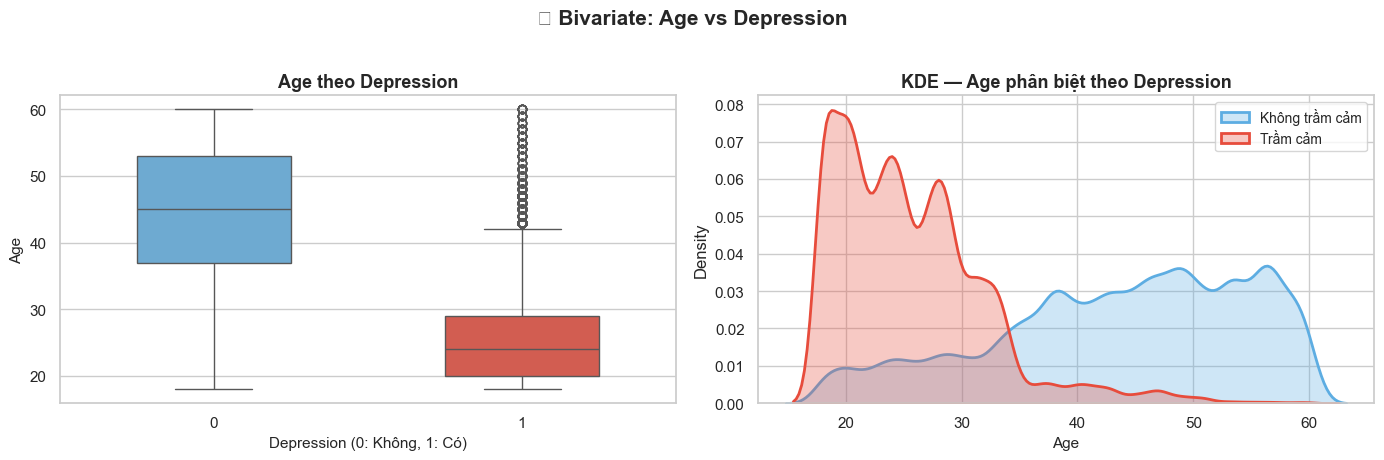

  Không trầm cảm: mean=43.68, median=45.00, std=10.88
  Trầm cảm: mean=25.55, median=24.00, std=6.49
----------------------------------------------------------------------


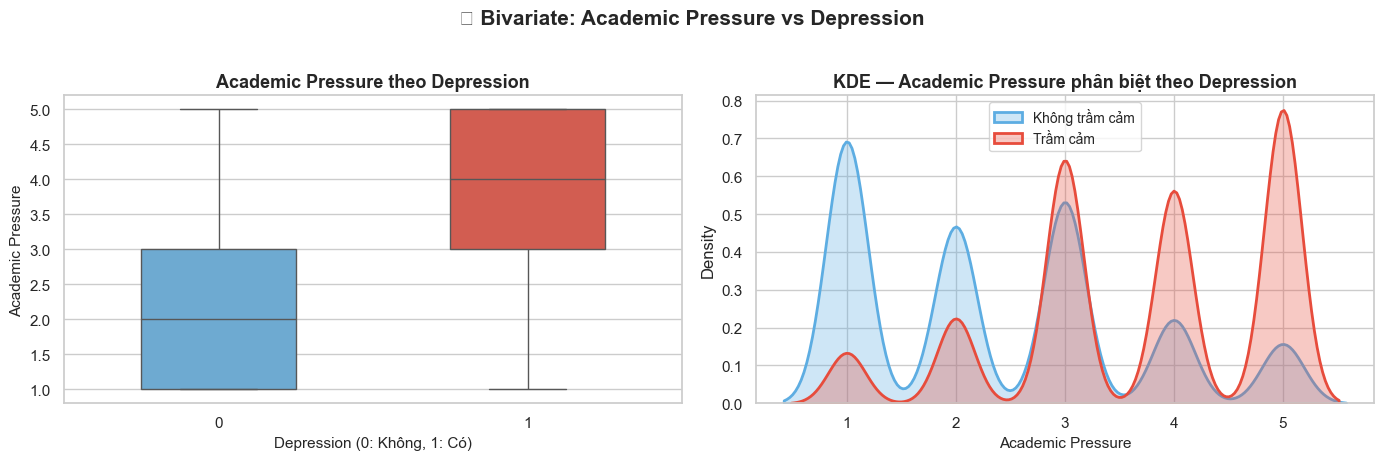

  Không trầm cảm: mean=2.36, median=2.00, std=1.25
  Trầm cảm: mean=3.69, median=4.00, std=1.19
----------------------------------------------------------------------


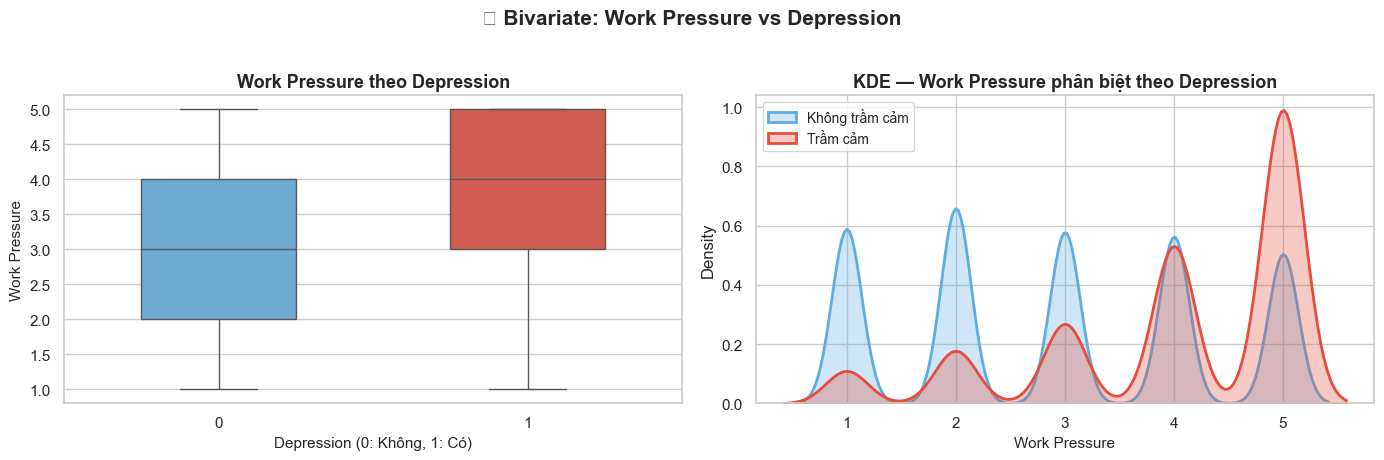

  Không trầm cảm: mean=2.91, median=3.00, std=1.39
  Trầm cảm: mean=4.02, median=4.00, std=1.19
----------------------------------------------------------------------


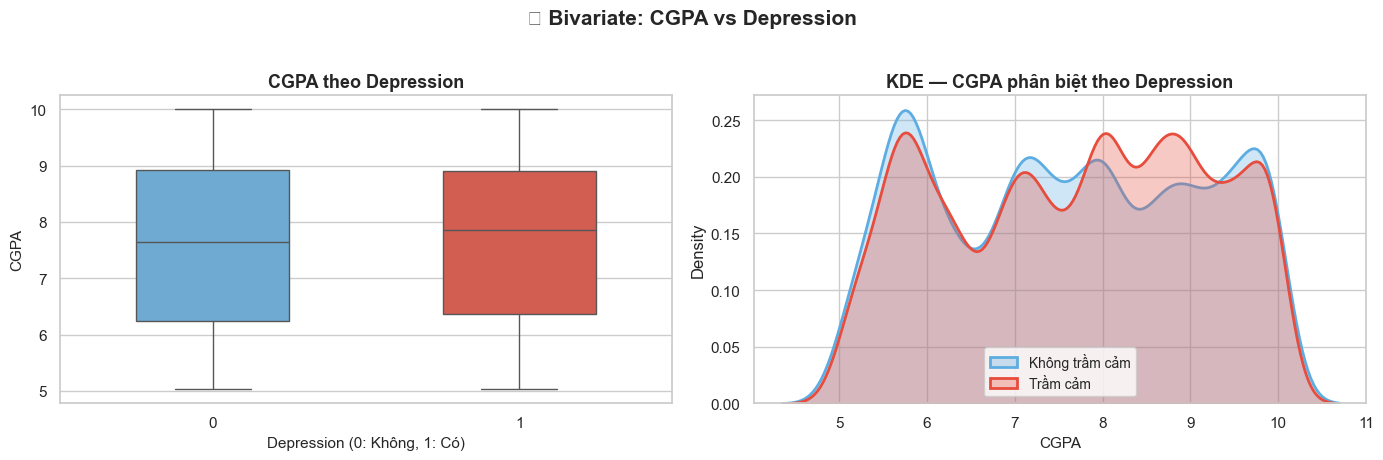

  Không trầm cảm: mean=7.62, median=7.64, std=1.48
  Trầm cảm: mean=7.69, median=7.85, std=1.45
----------------------------------------------------------------------


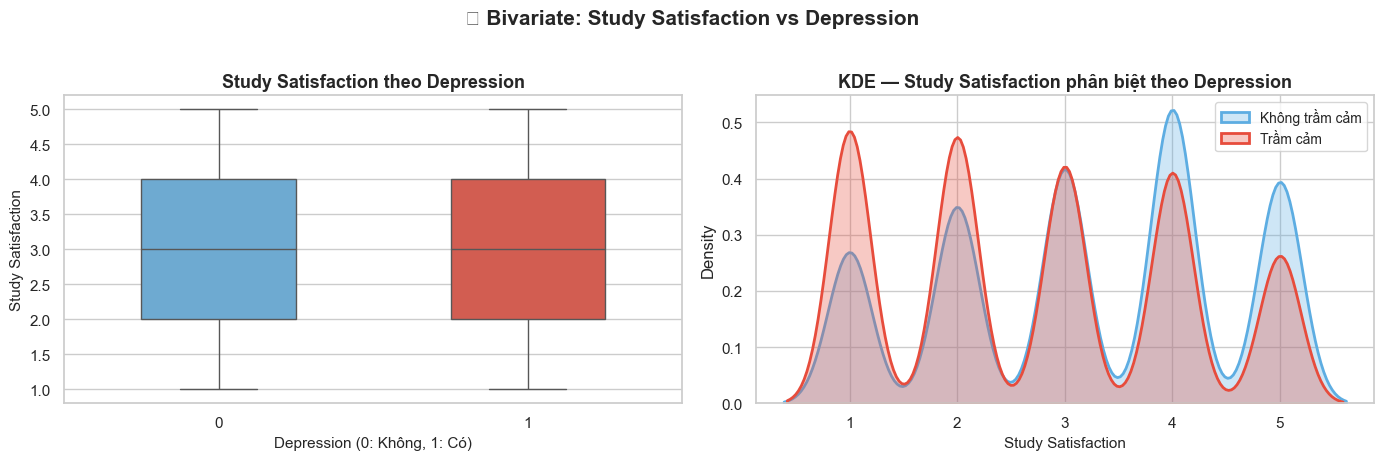

  Không trầm cảm: mean=3.22, median=3.00, std=1.33
  Trầm cảm: mean=2.75, median=3.00, std=1.35
----------------------------------------------------------------------


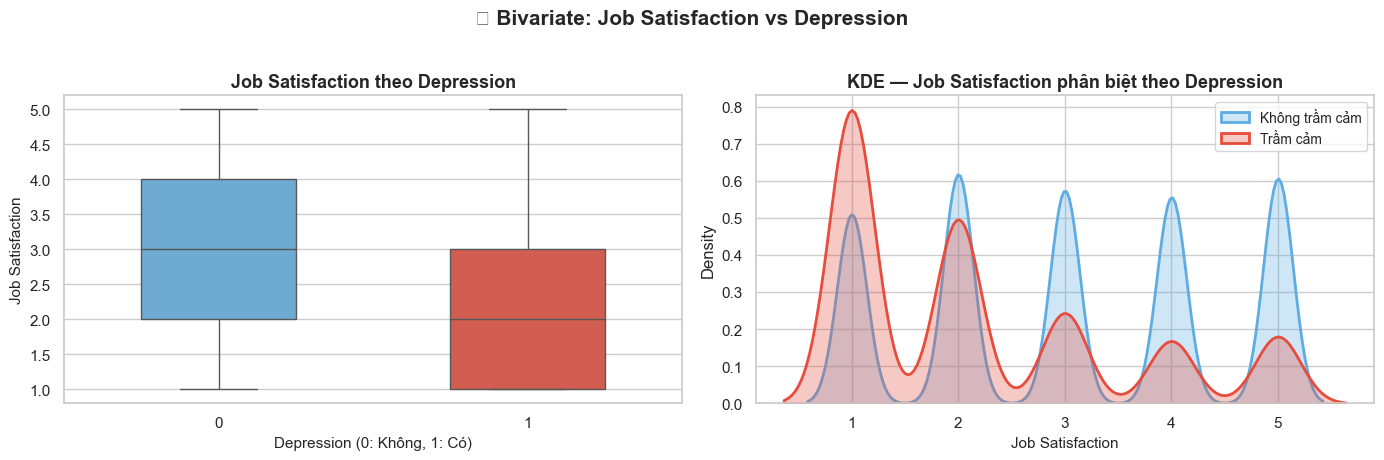

  Không trầm cảm: mean=3.05, median=3.00, std=1.40
  Trầm cảm: mean=2.17, median=2.00, std=1.32
----------------------------------------------------------------------


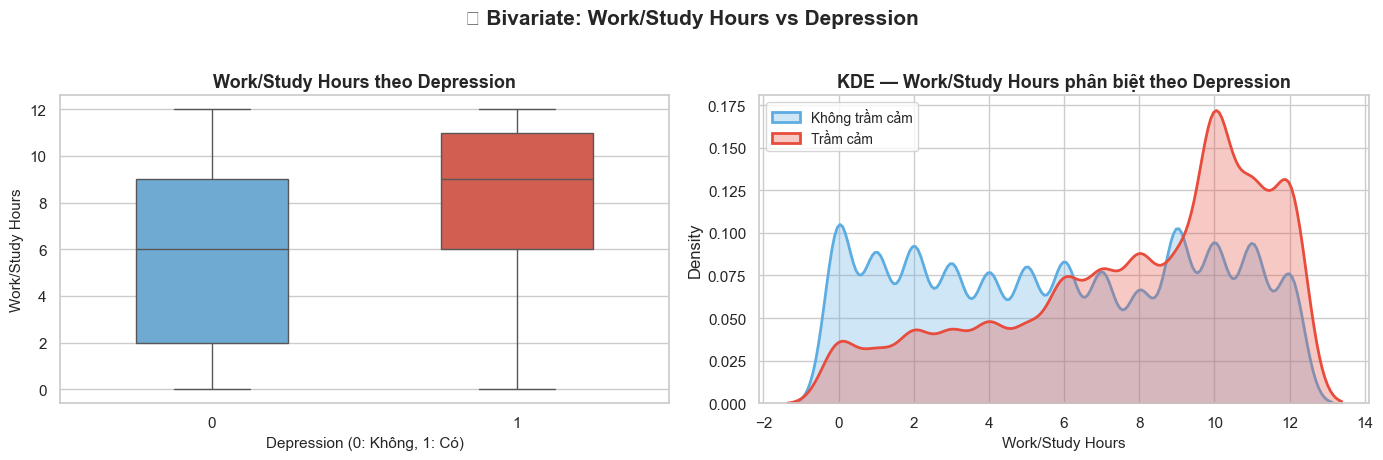

  Không trầm cảm: mean=5.90, median=6.00, std=3.85
  Trầm cảm: mean=7.82, median=9.00, std=3.48
----------------------------------------------------------------------


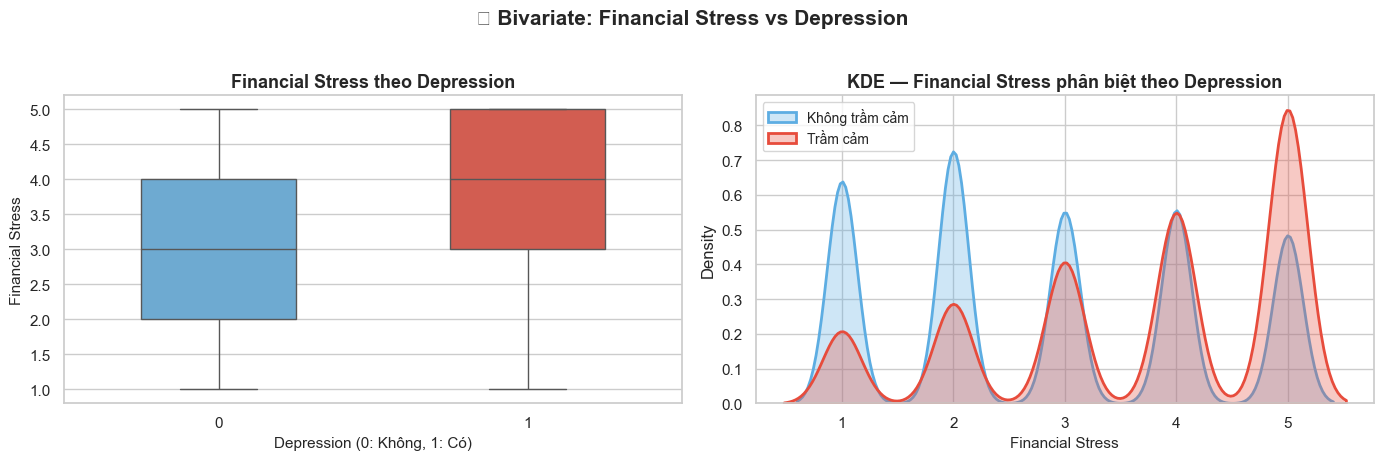

  Không trầm cảm: mean=2.84, median=3.00, std=1.39
  Trầm cảm: mean=3.67, median=4.00, std=1.32
----------------------------------------------------------------------


In [12]:
# Bivariate Analysis — Numerical features vs Depression
for col in numerical_cols:
    plot_numerical_vs_target(train_df, col, target='Depression')

### Nhận xét Bivariate — Numerical vs Depression

**Age** **(TÍN HIỆU MẠNH NHẤT)**: Đây là phát hiện nổi bật nhất! Nhóm trầm cảm có tuổi trung bình **25.5** (trẻ, chủ yếu 18-30), trong khi nhóm không trầm cảm có tuổi trung bình **43.7** (trung niên). Sự chênh lệch lên đến **18 tuổi** — KDE plot cho thấy 2 đường phân phối gần như tách biệt hoàn toàn. Đây là feature phân biệt Depression mạnh nhất (correlation = -0.565). Tuy nhiên, cần lưu ý: điều này cũng phản ánh việc nhóm trẻ tuổi = Student chiếm phần lớn trong nhóm trầm cảm.

**Academic Pressure** (TÍN HIỆU MẠNH): Nhóm trầm cảm có áp lực học tập cao hơn rõ rệt (mean=3.69 vs 2.36). Correlation = +0.475 — feature mạnh thứ 2.

**Work Pressure** (TÍN HIỆU VỪA): Nhóm trầm cảm từ dân đi làm chịu áp lực công việc cao hơn (mean=4.02 vs 2.91). Correlation = +0.217.

**CGPA** (KHÔNG CÓ TÍN HIỆU): Gần như không có sự khác biệt giữa 2 nhóm (7.69 vs 7.62). Correlation chỉ = +0.022 — điểm số học tập hầu như **không ảnh hưởng** đến trầm cảm.

**Study Satisfaction** (TÍN HIỆU VỪA): Nhóm trầm cảm kém hài lòng hơn (2.75 vs 3.22). Correlation = -0.168.

**Job Satisfaction** (TÍN HIỆU VỪA): Tương tự Study Satisfaction — nhóm trầm cảm kém hài lòng (2.17 vs 3.05). Correlation = -0.169.

**Work/Study Hours** (TÍN HIỆU VỪA): Nhóm trầm cảm làm/học nhiều giờ hơn (7.82 vs 5.90 giờ/ngày). Correlation = +0.192.

**Financial Stress** (TÍN HIỆU VỪA): Nhóm trầm cảm chịu stress tài chính cao hơn (3.67 vs 2.84). Correlation = +0.227.

**Tổng kết ranking tín hiệu**: `Age` >> `Academic Pressure` >> `Financial Stress` > `Work Pressure` > `Work/Study Hours` > `Job Satisfaction` ≈ `Study Satisfaction` >> `CGPA` (gần như vô dụng)

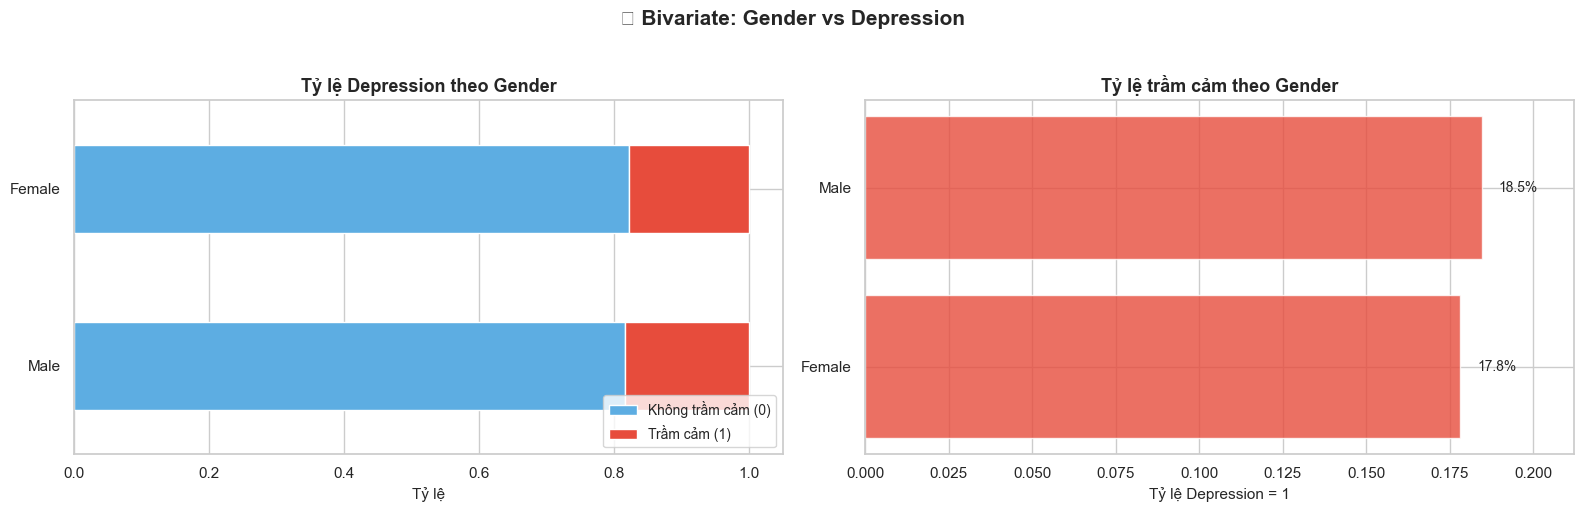

----------------------------------------------------------------------


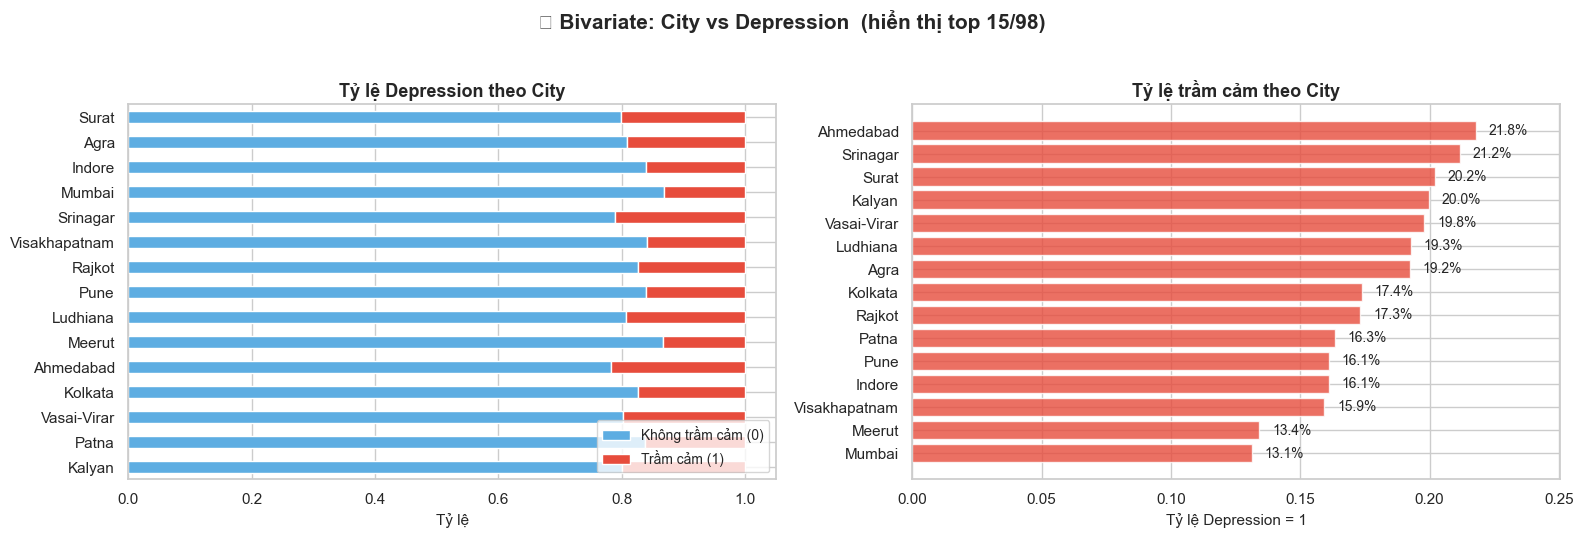

----------------------------------------------------------------------


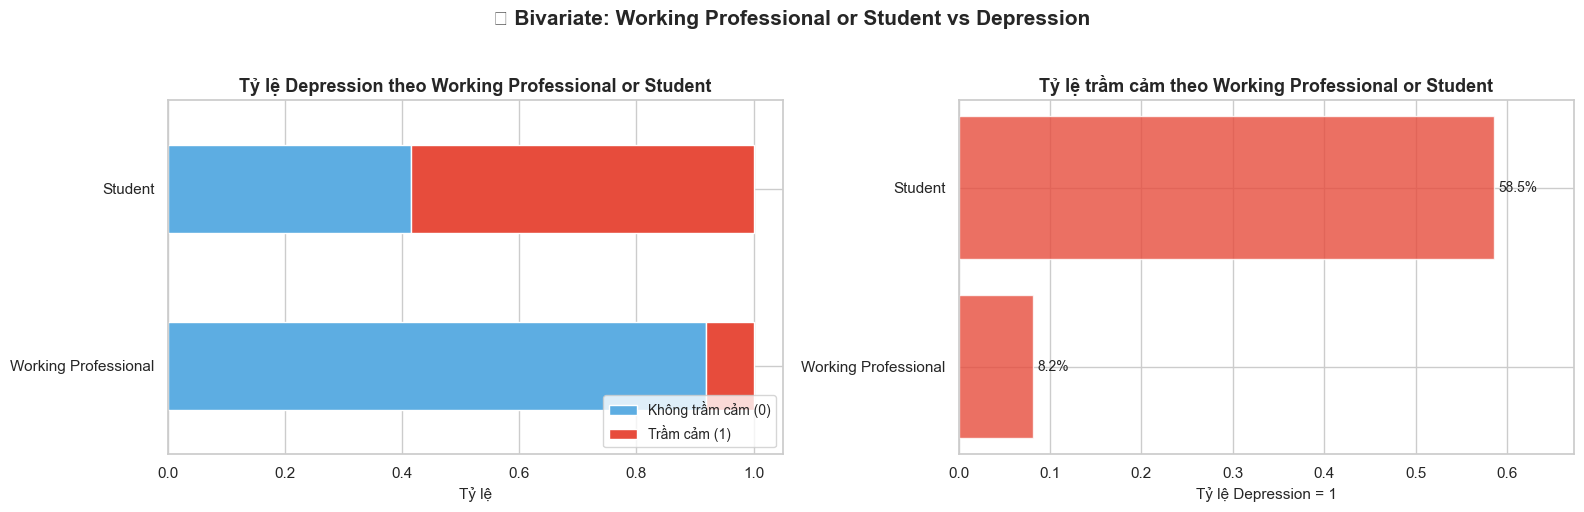

----------------------------------------------------------------------


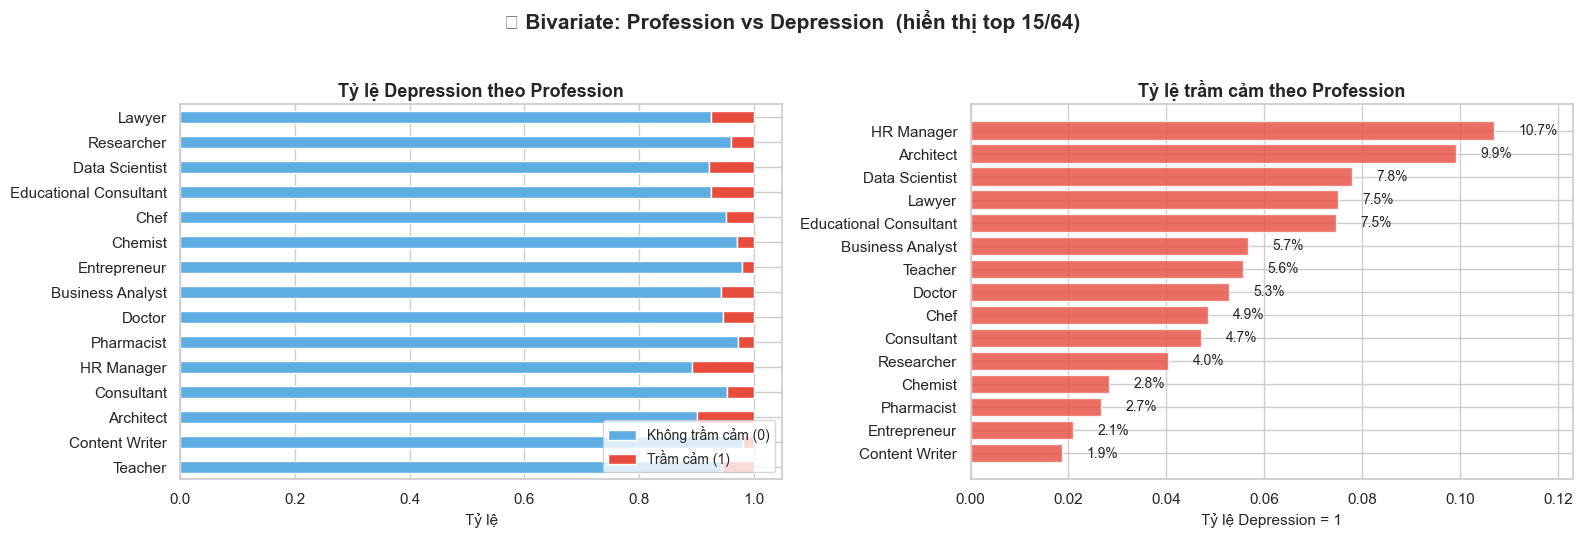

----------------------------------------------------------------------


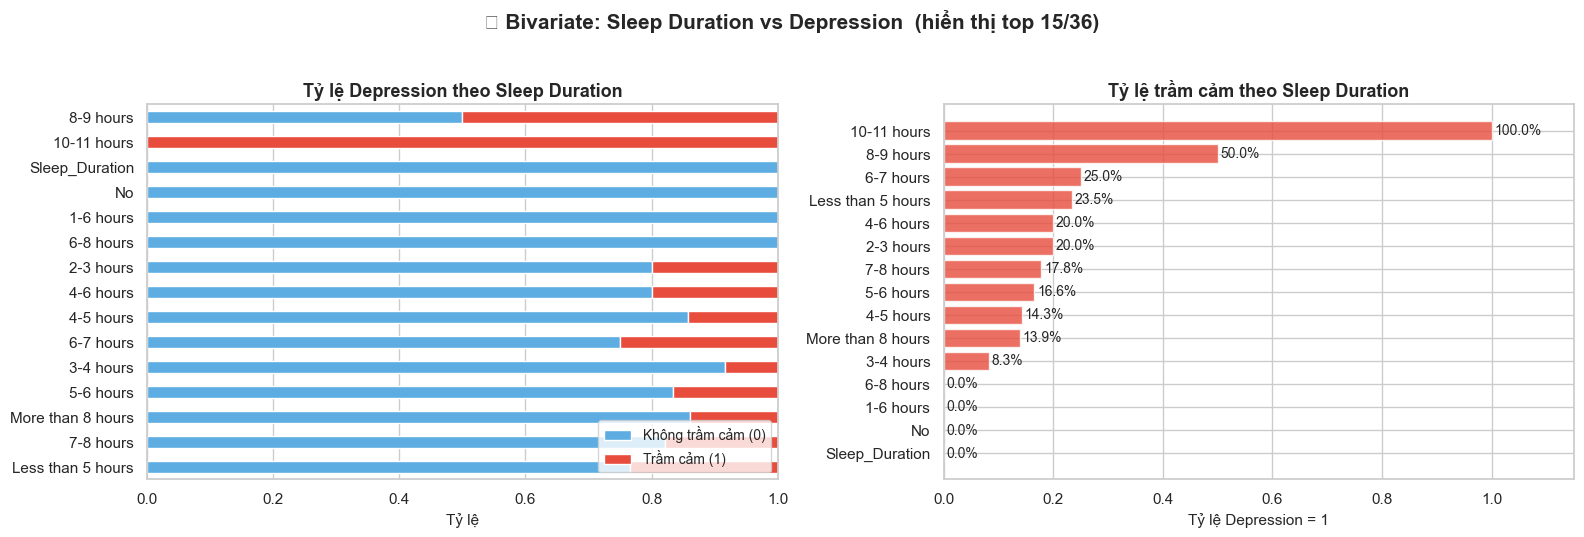

----------------------------------------------------------------------


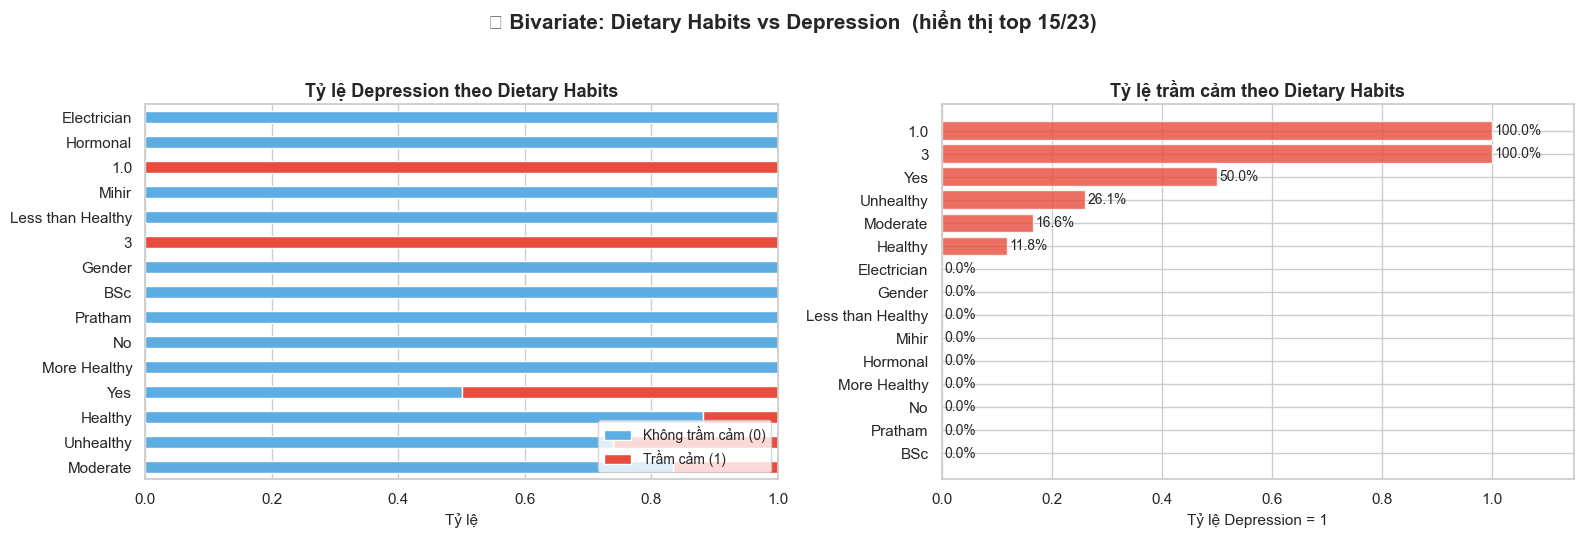

----------------------------------------------------------------------


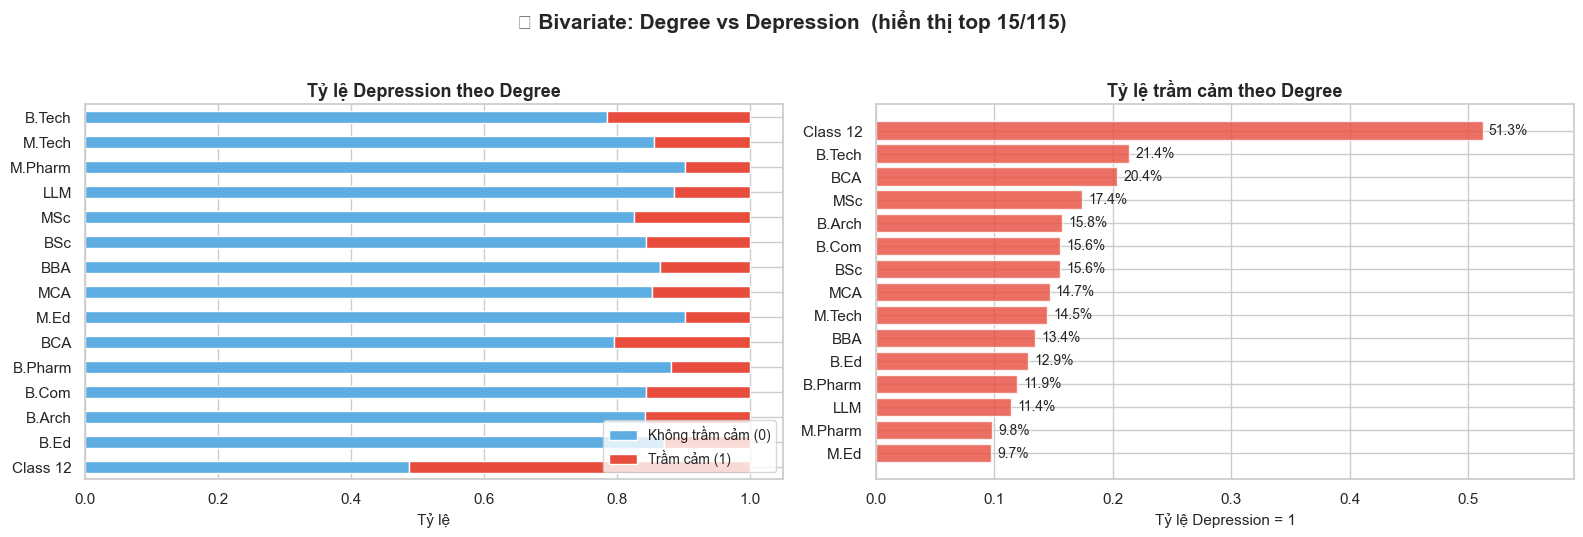

----------------------------------------------------------------------


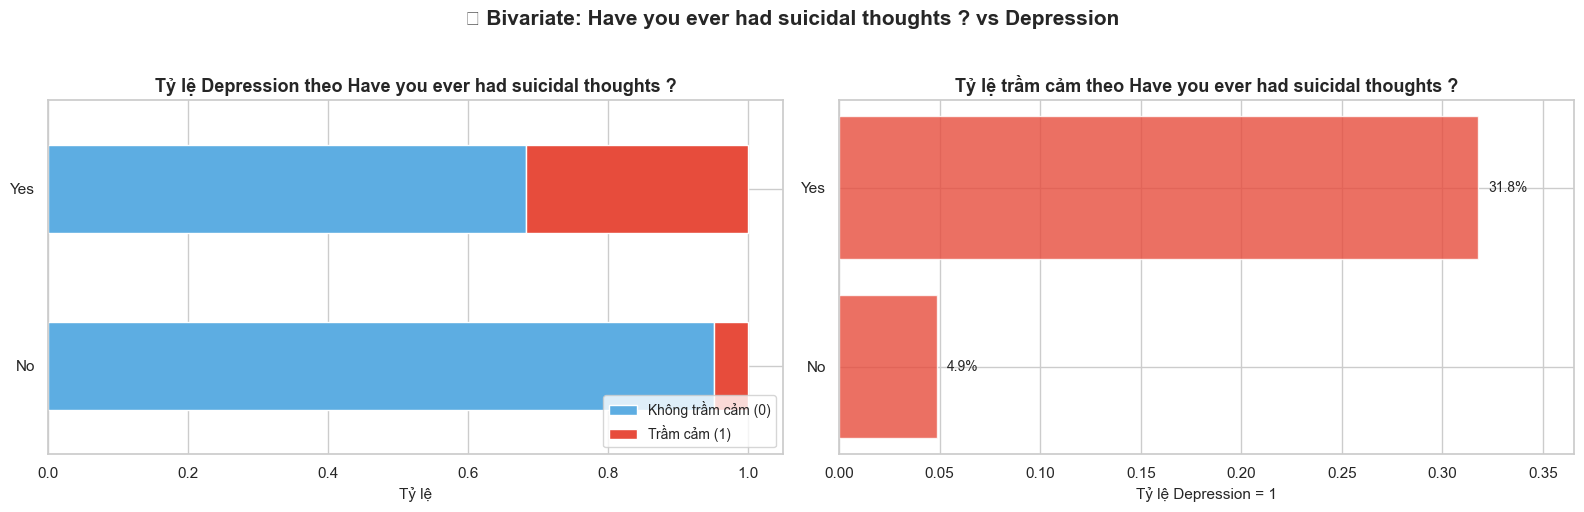

----------------------------------------------------------------------


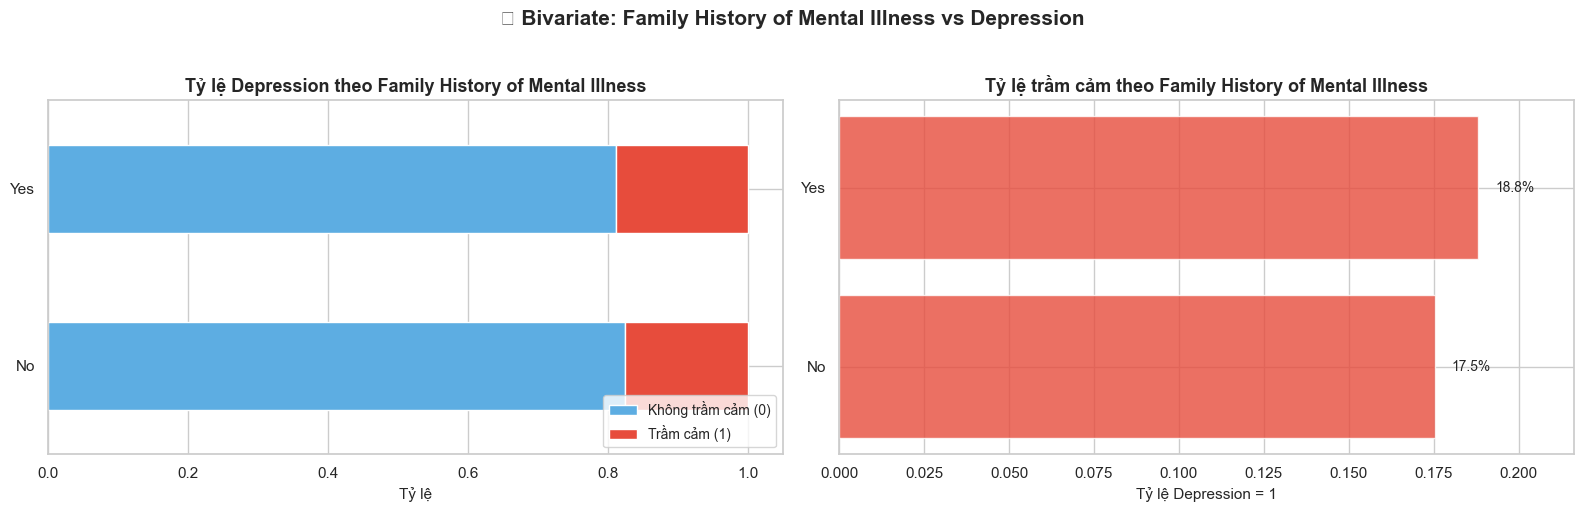

----------------------------------------------------------------------


In [13]:
# Bivariate Analysis — Categorical features vs Depression
for col in categorical_cols:
    plot_categorical_vs_target(train_df, col, target='Depression', top_n=15)

### Nhận xét Bivariate — Categorical vs Depression

**Working Professional or Student** **(TÍN HIỆU CỰC MẠNH)**: Đây là phát hiện **sốc** nhất — tỷ lệ trầm cảm ở **Sinh viên lên đến 58.5%** trong khi ở **Người đi làm chỉ 8.2%**. Nghĩa là sinh viên có nguy cơ trầm cảm **gấp 7 lần** so với người đi làm! Điều này giải thích tại sao `Age` có tương quan mạnh — tuổi trẻ = Student = tỷ lệ trầm cảm cao.

**Suicidal Thoughts** **(TÍN HIỆU CỰC MẠNH)**: Người từng có ý định tự tử có tỷ lệ trầm cảm **31.8%**, cao gấp **6.5 lần** so với người chưa từng (4.9%). Đây là signal rất trực quan — suy nghĩ tự tử là biểu hiện nghiêm trọng liên quan trực tiếp đến trầm cảm.

**Gender**: Tỷ lệ trầm cảm gần như bằng nhau giữa Male (18.5%) và Female (17.8%) — **giới tính không phải yếu tố phân biệt đáng kể** trong dataset này.

**Family History of Mental Illness**: Tỷ lệ trầm cảm chỉ chênh nhẹ: 18.8% (có tiền sử) vs 17.5% (không có tiền sử) — **yếu tố gia đình đơn lẻ ảnh hưởng ít**, nhưng có thể tạo interaction effect khi kết hợp với các yếu tố khác.

**Sleep Duration**: Nhìn qua 4 category chính: `Less than 5 hours` có tỷ lệ trầm cảm cao nhất (**23.5%**), rồi `7-8 hours` (17.8%), `5-6 hours` (16.6%), và `More than 8 hours` thấp nhất (13.9%). Ngủ ít → nguy cơ trầm cảm cao hơn.

**Dietary Habits**: Rõ ràng thấy gradient — `Unhealthy` (26.1%) > `Moderate` (16.6%) > `Healthy` (11.8%). Chế độ ăn uống không lành mạnh liên quan đến tỷ lệ trầm cảm **gấp đôi** so với ăn lành mạnh.

**City, Profession, Degree**: Do high cardinality, khó phân tích trên biểu đồ tổng thể. Tuy nhiên, một số nghề nghiệp/thành phố cụ thể có thể có tỷ lệ trầm cảm khác biệt — cần Target Encoding để khai thác.

**Tổng kết**: `Working Professional or Student` và `Suicidal Thoughts` là 2 yếu tố categorical tạo ra sự phân biệt Depression **mạnh mẽ nhất**. `Dietary Habits` và `Sleep Duration` cũng cho thấy pattern rõ ràng.

---
## 1.7 Multivariate Analysis — Tương Tác Đa Biến

Phân tích sự kết hợp của 2-3 features với nhau để khám phá **tương tác (interaction)** mà univariate / bivariate không thể hiện được. Những phát hiện ở phần này sẽ là **tiền đề quan trọng** cho việc tạo interaction features ở GĐ2b (Feature Engineering).

**Các tổ hợp phân tích**:
1. `Sleep Duration` × `Financial Stress` → Depression
2. `Suicidal Thoughts` × `Family History` → Depression
3. `Work/Study Hours` × `Age Group` → Depression

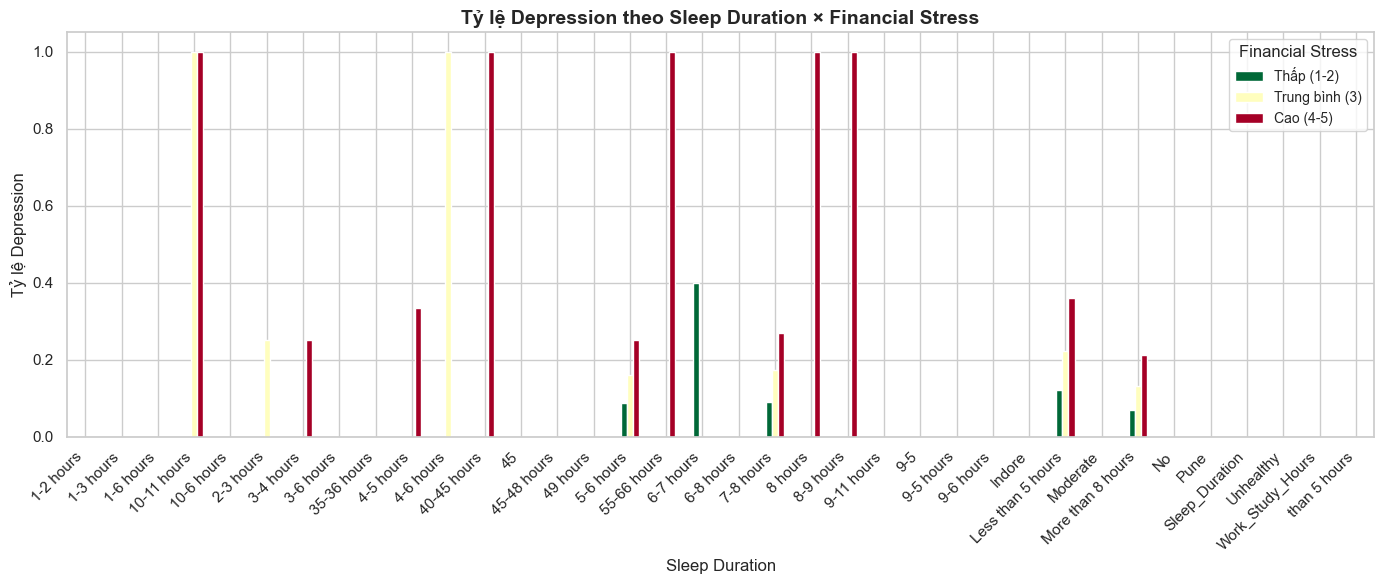

In [14]:
# === Multivariate 1: Sleep Duration × Financial Stress × Depression ===

train_temp = train_df.copy()
train_temp['FinStress_Group'] = pd.cut(
    train_temp['Financial Stress'],
    bins=[0, 2, 3, 5],
    labels=['Thấp (1-2)', 'Trung bình (3)', 'Cao (4-5)'],
    include_lowest=True
)

ct = pd.crosstab(
    [train_temp['Sleep Duration'], train_temp['FinStress_Group']],
    train_temp['Depression'],
    normalize='index'
)

fig, ax = plt.subplots(figsize=(14, 6))
if 1 in ct.columns:
    ct[1].unstack().plot(kind='bar', ax=ax, colormap='RdYlGn_r', edgecolor='white')
    ax.set_title('Tỷ lệ Depression theo Sleep Duration × Financial Stress',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Tỷ lệ Depression', fontsize=12)
    ax.set_xlabel('Sleep Duration', fontsize=12)
    ax.legend(title='Financial Stress', fontsize=10)
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

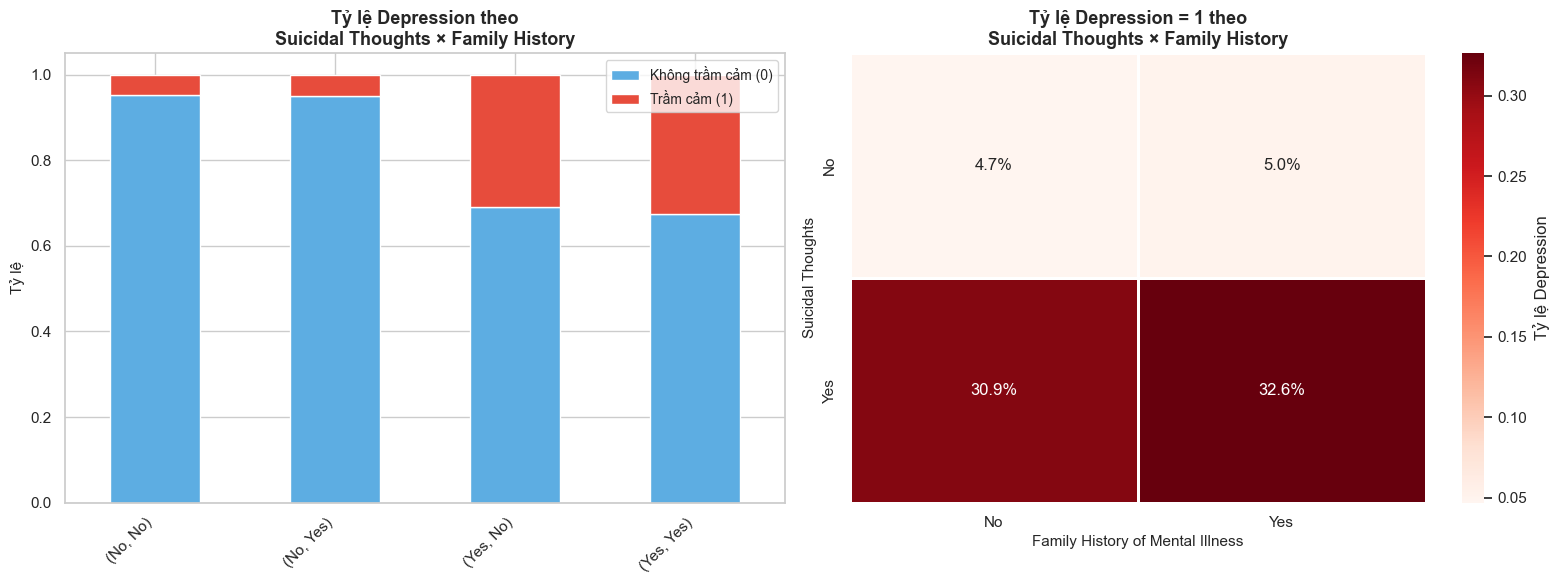

In [15]:
# === Multivariate 2: Suicidal Thoughts × Family History × Depression ===

ct2 = pd.crosstab(
    [train_df['Have you ever had suicidal thoughts ?'],
     train_df['Family History of Mental Illness']],
    train_df['Depression']
)
ct2_pct = ct2.div(ct2.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar chart
ct2_pct.plot(kind='bar', stacked=True, ax=axes[0],
             color=['#5DADE2', '#E74C3C'], edgecolor='white')
axes[0].set_title('Tỷ lệ Depression theo\nSuicidal Thoughts × Family History',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Tỷ lệ', fontsize=11)
axes[0].set_xlabel('')
axes[0].legend(['Không trầm cảm (0)', 'Trầm cảm (1)'], fontsize=10)
plt.sca(axes[0])
plt.xticks(rotation=45, ha='right')

# Heatmap — tỷ lệ Depression = 1
if 1 in ct2_pct.columns:
    dep_rate = ct2_pct[1].unstack()
    sns.heatmap(dep_rate, annot=True, fmt='.1%', cmap='Reds',
                ax=axes[1], linewidths=1, cbar_kws={'label': 'Tỷ lệ Depression'})
    axes[1].set_title('Tỷ lệ Depression = 1 theo\nSuicidal Thoughts × Family History',
                      fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Family History of Mental Illness', fontsize=11)
    axes[1].set_ylabel('Suicidal Thoughts', fontsize=11)

plt.tight_layout()
plt.show()

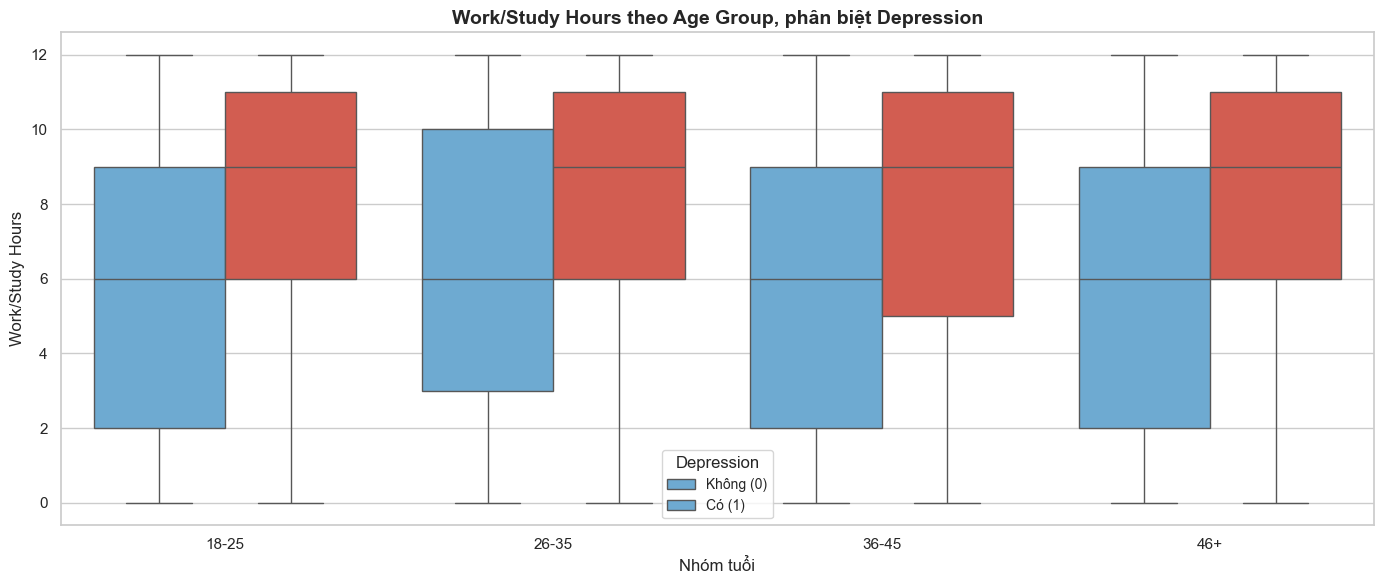

In [16]:
# === Multivariate 3: Work/Study Hours × Age Group × Depression ===

train_temp = train_df.copy()
train_temp['Age_Group'] = pd.cut(
    train_temp['Age'],
    bins=[0, 25, 35, 45, 100],
    labels=['18-25', '26-35', '36-45', '46+']
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=train_temp, x='Age_Group', y='Work/Study Hours',
    hue='Depression', palette={0: '#5DADE2', 1: '#E74C3C', '0': '#5DADE2', '1': '#E74C3C'}, ax=ax
)
ax.set_title('Work/Study Hours theo Age Group, phân biệt Depression',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Nhóm tuổi', fontsize=12)
ax.set_ylabel('Work/Study Hours', fontsize=12)
ax.legend(title='Depression', labels=['Không (0)', 'Có (1)'], fontsize=10)

plt.tight_layout()
plt.show()

### Nhận xét Multivariate Analysis

**Sleep Duration × Financial Stress**:
- Khi kết hợp 2 yếu tố, thấy rõ **hiệu ứng cộng gộp**: người ngủ ít (`Less than 5 hours`) VÀ có stress tài chính cao (`4-5`) có tỷ lệ trầm cảm cao nhất.
- Ngược lại, ngủ đủ (`More than 8 hours`) + stress tài chính thấp → tỷ lệ trầm cảm thấp nhất.
- Đây là bằng chứng cho interaction feature `Sleep × Financial Stress` có thể hữu ích ở GĐ2b.

**Suicidal Thoughts × Family History** **(PHÁT HIỆN QUAN TRỌNG)**:
- Khi **cả hai yếu tố rủi ro đều có** (có ý định tự tử + có tiền sử gia đình): tỷ lệ trầm cảm = **32.6%**
- Chỉ có ý định tự tử (không có tiền sử gia đình): tỷ lệ = **30.9%**
- Chỉ có tiền sử gia đình (không có ý định tự tử): tỷ lệ = **5.0%**
- Không có yếu tố nào: tỷ lệ = **4.7%**
- **Insight**: `Suicidal Thoughts` là yếu tố chi phối gần như tuyệt đối (4.7% → 30.9% khi thêm), trong khi `Family History` đơn lẻ chỉ tăng nhẹ (4.7% → 5.0%). Tuy nhiên, khi **cả hai kết hợp**, tỷ lệ đạt đỉnh 32.6% — cho thấy interaction effect nhẹ. → Nên tạo `Risk_Score = Suicidal_Thoughts + Family_History` ở GĐ2b.

**Work/Study Hours × Age Group** :
- Nhóm tuổi 18-25 có sự phân biệt rõ nhất: nhóm trầm cảm làm/học **nhiều giờ hơn** rõ rệt so với nhóm không trầm cảm.
- Ở nhóm 36-45 và 46+, sự khác biệt giờ làm giữa 2 nhóm Depression **giảm hơn một tí**.
- **Insight**: Tải công việc/học tập ảnh hưởng đến trầm cảm **mạnh hơn một chút ở nhóm trẻ** → interaction `Age × Work_Study_Hours` có thể có giá trị.

**Kết luận cho Feature Engineering (GĐ2b)**:
- `Risk_Score = Suicidal_Thoughts + Family_History`
- `Pressure × Financial_Stress` (kết hợp stress kép)
- `Age × Work_Study_Hours` (tải theo tuổi)
- Yếu tố khi kết hợp tăng nguy cơ trầm cảm đột biến nhất: **Suicidal Thoughts + bất kỳ yếu tố stress nào** → tỷ lệ nhảy từ ~5% lên ~30%+

---
## 1.8 Correlation Analysis

Phân tích tương quan giữa các numerical features và target `Depression` thông qua **heatmap Pearson correlation**. Mục tiêu:
- Phát hiện **multicollinearity** giữa các features (cặp features tương quan cao với nhau)
- Xác định features có **tương quan mạnh nhất** với target để ưu tiên trong modeling

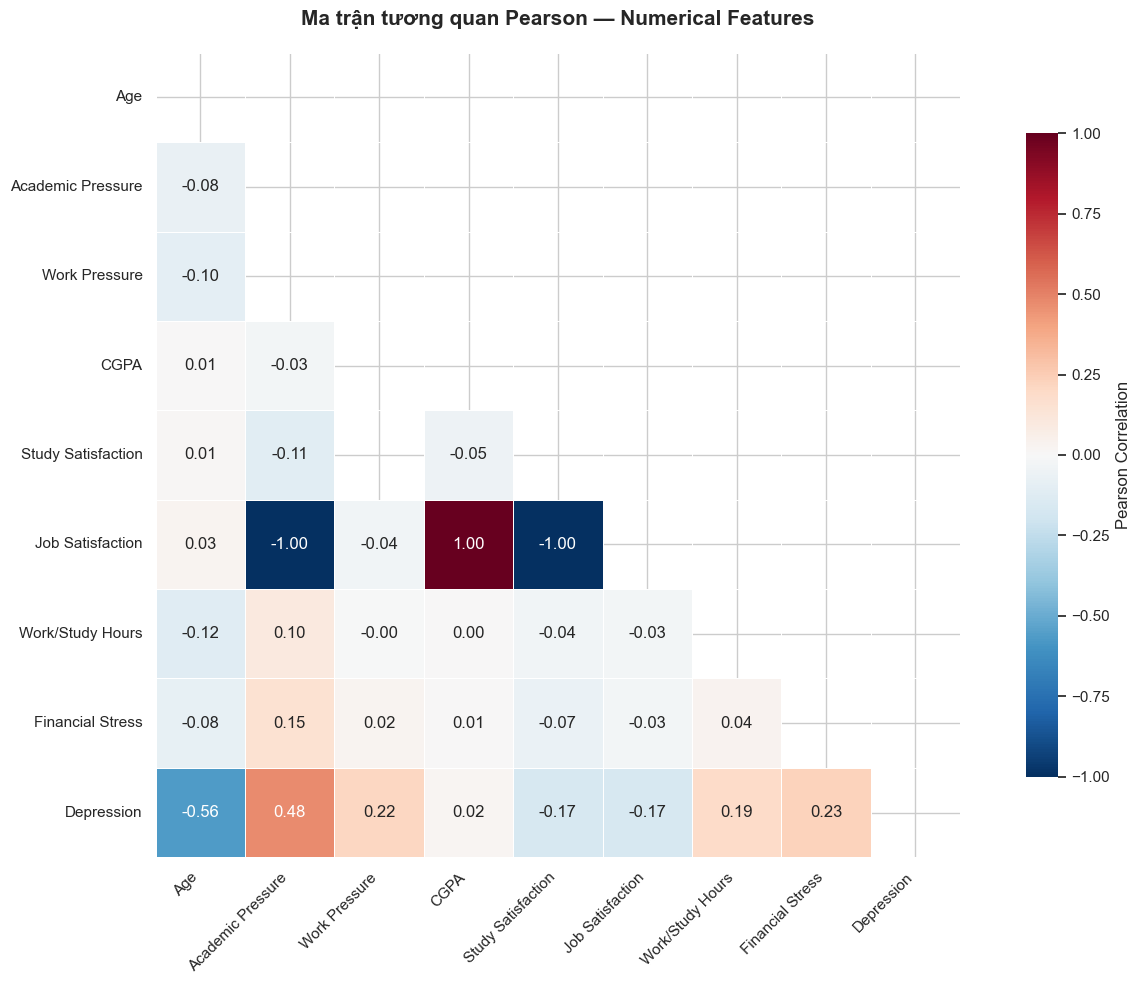

In [17]:
# Correlation Heatmap — Numerical features + Depression
num_cols_for_corr = numerical_cols + ['Depression']
corr_matrix = train_df[num_cols_for_corr].corr()

plot_correlation_heatmap(corr_matrix, figsize=(14, 10))

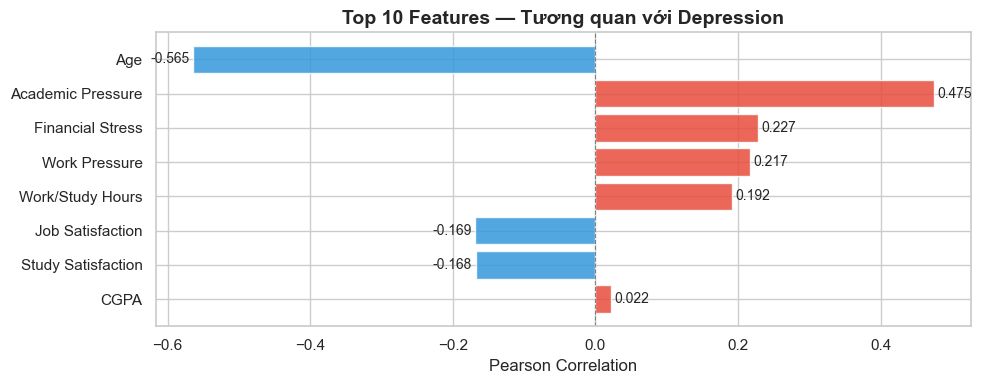


📋 Tương quan với Depression:
  Age                           : -0.5647  (↓ Âm)
  Academic Pressure             : +0.4750  (↑ Dương)
  Financial Stress              : +0.2272  (↑ Dương)
  Work Pressure                 : +0.2166  (↑ Dương)
  Work/Study Hours              : +0.1917  (↑ Dương)
  Job Satisfaction              : -0.1685  (↓ Âm)
  Study Satisfaction            : -0.1680  (↓ Âm)
  CGPA                          : +0.0217  (↑ Dương)


In [18]:
# Top features tương quan mạnh nhất với Depression
plot_top_correlations(corr_matrix, target='Depression', top_n=10)

### Nhận xét Correlation Analysis

**Top features tương quan với Depression** (xếp theo |correlation|):
1. `Age`: **-0.565** (âm mạnh) — tuổi trẻ = nguy cơ trầm cảm cao
2. `Academic Pressure`: **+0.475** (dương mạnh) — áp lực học tập cao = tăng nguy cơ
3. `Financial Stress`: **+0.227** — stress tài chính tăng = tăng nguy cơ
4. `Work Pressure`: **+0.217** — áp lực công việc tăng = tăng nguy cơ
5. `Work/Study Hours`: **+0.192** — làm/học nhiều giờ = tăng nguy cơ
6. `Job Satisfaction`: **-0.169** — hài lòng công việc = giảm nguy cơ
7. `Study Satisfaction`: **-0.168** — hài lòng học tập = giảm nguy cơ
8. `CGPA`: **+0.022** — **gần như không tương quan** → có thể cân nhắc loại bỏ hoặc tạo feature mới

**Multicollinearity**:
- Không phát hiện cặp features nào có tương quan cực cao (>0.8) với nhau trong ma trận hiện tại.
- Tuy nhiên, cần lưu ý rằng nhiều giá trị trong ma trận bị ảnh hưởng bởi missing values (conditional missing) — ví dụ `Academic Pressure` và `Work Pressure` gần như không bao giờ xuất hiện cùng lúc, nên correlation giữa chúng không có ý nghĩa.
- Sau khi merge thành `Pressure` và `Satisfaction` ở GĐ2, cần tính lại correlation.

**Pattern tổng thể**: Các yếu tố **stress/áp lực** (Academic Pressure, Work Pressure, Financial Stress) đều tương quan **dương** với Depression, trong khi yếu tố **hài lòng** (Study Satisfaction, Job Satisfaction) tương quan **âm**. Điều này hoàn toàn hợp lý từ góc độ tâm lý học — stress tăng + hài lòng giảm = nguy cơ trầm cảm cao.

---
## 1.9 Key Findings & Đề Xuất Cho GĐ2

### Tổng kết các phát hiện quan trọng

**1. Sinh viên là nhóm rủi ro trầm cảm cực kỳ cao**
Tỷ lệ trầm cảm ở sinh viên lên đến **58.5%** — gấp **7 lần** so với người đi làm (8.2%). Đây là phát hiện nổi bật nhất, giải thích tại sao `Age` có tương quan âm mạnh nhất với Depression (-0.565): tuổi trẻ đồng nghĩa với nhóm sinh viên đang chịu áp lực học tập căng thẳng.

**2. Ý định tự tử là chỉ báo mạnh và trực tiếp nhất**
Người từng có ý định tự tử có tỷ lệ trầm cảm **31.8%**, cao gấp **6.5 lần** so với nhóm chưa từng (4.9%). Khi kết hợp thêm tiền sử bệnh tâm thần gia đình, tỷ lệ tăng lên 32.6% — xác nhận hiệu ứng cộng gộp của hai yếu tố rủi ro.

**3. Áp lực là yếu tố quyết định, không phải thành tích**
`Academic Pressure` tương quan dương mạnh với Depression (corr = +0.475), trong khi `CGPA` gần như vô nghĩa (corr = +0.022). Kết luận: trầm cảm không đến từ việc học kém, mà đến từ cảm giác bị áp lực. Tương tự, `Work Pressure` (corr = +0.217) và `Financial Stress` (corr = +0.227) đều làm tăng nguy cơ.

**4. Lối sống ảnh hưởng rõ ràng theo gradient**
Ngủ ít hơn 5 giờ/đêm có tỷ lệ trầm cảm 23.5%, cao hơn gần 2 lần so với ngủ đủ (>8 giờ: 13.9%). Ăn uống không lành mạnh (26.1%) cũng có tỷ lệ trầm cảm gấp đôi so với ăn lành mạnh (11.8%). Cả hai tạo thành gradient rõ ràng — lối sống kém = nguy cơ cao.

**5. Giới tính không phải yếu tố rủi ro đáng kể**
Tỷ lệ trầm cảm ở Nam (18.5%) và Nữ (17.8%) gần như bằng nhau. Tiền sử gia đình đơn lẻ cũng chỉ chênh nhẹ (18.8% vs 17.5%), nhưng tạo interaction effect đáng kể khi kết hợp với ý định tự tử.

**6. Dataset bị nhiễm dữ liệu bẩn ở 2 cột quan trọng**
`Sleep Duration` có 32 giá trị bất hợp lệ (tên thành phố, tên người, tên cột khác bị swap vào — ~79 mẫu). `Dietary Habits` có 20 giá trị bất hợp lệ tương tự (~27 mẫu). Tuy ít nhưng cần xử lý trước khi encoding để tránh nhiễu.

**7. Missing values có hệ thống và có thể khai thác**
Pattern conditional missing hoàn toàn nhất quán: Student thiếu cột Worker và ngược lại. Dataset đồng thời bị imbalanced vừa phải (82:18) — đủ để cần quan tâm nhưng chưa đến mức phải oversampling aggressively. Cần dùng F1-score làm metric chính thay vì accuracy.

---

### Đề xuất cho GĐ2 (Preprocessing & Feature Engineering)

**GĐ2a — Preprocessing (`02_preprocessing.ipynb`)**:

| Vấn đề | Chiến lược xử lý | Lý do |
|---|---|---|
| Conditional missing (`Academic Pressure`, `Work Pressure`, ...) | **Merge**: tạo cột gộp `Pressure` và `Satisfaction` | Bảo toàn ý nghĩa semantic, tránh tạo giá trị giả |
| `CGPA` missing ở Workers | Fill = 0 hoặc tạo flag `has_CGPA` | CGPA không áp dụng cho Worker |
| Missing ít (`Dietary Habits`: 4, `Degree`: 2, `Financial Stress`: 4) | Fill = mode hoặc drop mẫu | Số lượng không đáng kể |
| `Sleep Duration` dirty (32 non-standard values) | Map về 4 category chuẩn, các giá trị bẩn → `NaN` rồi fill mode | Chỉ ~79 mẫu bị ảnh hưởng |
| `Dietary Habits` dirty (20 non-standard values) | Chỉ giữ 3 category chính, còn lại → `NaN` rồi fill mode | Chỉ ~27 mẫu bị ảnh hưởng |
| Outliers | Không cần xử lý | Không phát hiện outliers đáng kể (IQR method) |
| Encoding binary | Label Encoding (0/1): `Gender`, `Suicidal Thoughts`, `Family History`, `Working Professional or Student` | Chỉ 2 categories |
| Encoding ordinal | Ordinal mapping: `Sleep Duration` (Less<5-6<7-8<More than 8), `Dietary Habits` (Unhealthy<Moderate<Healthy) | Có thứ tự tự nhiên |

**GĐ2b — Feature Engineering (`03_feature_engineering.ipynb`)**:

| Feature mới | Công thức / Cách tạo | Lý do (từ EDA) |
|---|---|---|
| `Risk_Score` | `Suicidal_Thoughts + Family_History` | Hai yếu tố rủi ro kép: kết hợp cho tỷ lệ trầm cảm 32.6% |
| `Pressure` | `Academic_Pressure` (Student) hoặc `Work_Pressure` (Professional) | Merge conditional columns |
| `Satisfaction` | `Study_Satisfaction` (Student) hoặc `Job_Satisfaction` (Professional) | Merge conditional columns |
| `Stress_Index` | `Pressure × Financial_Stress` | Stress kép: áp lực + tài chính |
| `Age_Group` | Bin Age: 18-25 / 26-35 / 36-45 / 46+ | Phân tách rõ nhóm sinh viên (18-25) rủi ro cao |
| `WorkLoad_by_Age` | `Age × Work_Study_Hours` | Tải công việc ảnh hưởng mạnh hơn ở nhóm trẻ |
| Target Encoding | `City` (98 unique), `Profession` (64 unique), `Degree` (115 unique) | High cardinality — không thể One-Hot Encoding |
| Cân nhắc loại bỏ | `CGPA` | Tương quan với Depression gần như bằng 0 (+0.022) |

---
*Kết thúc notebook EDA. Các phát hiện trên sẽ được sử dụng làm cơ sở cho GĐ2 Preprocessing & Feature Engineering.*
